# **Proyecto Integrador**

---

> *"Y será predicado este evangelio del reino en todo el mundo, por testimonio a todos los Gentiles; y entonces vendrá el fin".*
>
> — Mateo 24:14

---

# ***LUMINA* - La Biblia Viva con IA**
Plataforma conversacional que facilita la comprensión y aplicación contextual del texto bíblico mediante NLP y RAG, con un enfoque responsable, trazable y centrado en el usuario.

---

### **Avance 1: Análisis Exploratorio de Datos (EDA)**
**Equipo:** *#19*  
**Curso:** *Proyecto Integrador*  
**Posgrado:** *MNA - Maestría en Inteligencia Artificial Aplicada*  
**Institución:** Tecnológico de Monterrey  
**Fecha:** *30 de enero del 2026*  

---

### **Miembros del equipo**
- **A01732505** - Steven Sebastian Brutscher Cortez
- **A01795323** - Anghelo Daniel Pérez Martínez
- **A01423059** - Esmeralda González García

---

> *Este notebook corresponde al **Avance 1: Análisis Exploratorio de Datos (EDA)** del curso Proyecto Integrador de la Maestría en Inteligencia Artificial Aplicada (MNA) del Tecnológico de Monterrey*

De acuerdo con **CRISP-ML(Q)**, este trabajo se ubica principalmente en la fase de:

- **Data Engineering / Data Preparation** (Selección, diagnóstico, limpieza, estandarización y estructuración del dataset)
- Conecta con la fase previa (**Business & Data Understanding**) al validar la **factibilidad técnica** desde los datos reales.

---

> *"Porque somos hechura suya, criados en Cristo Jesús para buenas obras, las cuales Dios preparó para que anduviésemos en ellas".*
>
> — Efesios 2:10

---

## **Objetivos de aprendizaje**
- Elegir características relevantes para reducir dimensionalidad y aumentar generalización.
- Identificar, abordar y corregir problemas en los datos: faltantes, atípicos, alta cardinalidad, etc.

Aunque CRISP-ML(Q) suele ejemplificarse con datos tabulares numéricos/categóricos, en NLP (texto) estos conceptos se traducen a:
- **Calidad del texto** (ruido, caracteres extraños, duplicados, inconsistencias)
- **Estructura y metadatos** (libro/capítulo/versículo, versionado, normalización de referencias)
- **Cardinalidades** (número de libros/capítulos/versículos únicos, longitudes de texto, distribución por libro/testamento)
- **“Outliers”** (versículos extremadamente largos/cortos, símbolos raros, líneas vacías)
- **Distribuciones** (longitud de versículos, tokens/palabras, densidad por libro, etc.)

## **Dataset seleccionado (Corpus bíblico en español)**

Para el trimestre se decidió trabajar **solo en español**, por alcance y reproducibilidad.

### **Corpus base (oficial del repositorio y del EDA)**
- **RV1909 – Reina-Valera 1909**
- Motivos:
  - Permite **publicación y trazabilidad** del texto (uso abierto / reproducible).
  - Estructura clara por versículo, útil para RAG y evaluación.
  - Estabilidad para EDA, embeddings e indexado vectorial.
  - Dominio 100% público.

### **Versión visible al usuario (capa UX)**
- **VBL - Versión Biblia Libre**
- Motivo:
  - Lenguaje más moderno para experiencia del usuario.
  - Se usa como **capa de presentación**, sin romper trazabilidad (las referencias bíblicas se mantienen por versículo).
  - Dominio 100% público.

### **Procedencia del dataset**
El corpus se obtiene del proyecto **BibleNLP / eBible corpus**, disponible en:
- Hugging Face: `bible-nlp/biblenlp-corpus` (https://huggingface.co/datasets/bible-nlp/biblenlp-corpus)
- GitHub: `BibleNLP/ebible-corpus` (https://github.com/BibleNLP/ebible)

El formato base es **texto por versículo** (verse-per-line) y se alinea a una lista canónica de referencias (`vref.txt`), lo que permite construir una tabla estructurada:
- `book`, `chapter`, `verse`, `reference_id`, `text`, `translation`

## **Alcance del EDA en este notebook**

Este EDA cubre:

1) **Carga del corpus** (RV1909 y versión visible VBL/SBLM)  
2) **Estructuración tabular** (CSV/Parquet/DF) con referencias bíblicas  
3) **Diagnóstico** de:
   - Valores faltantes / líneas vacías
   - Duplicados (verso duplicado, referencia duplicada)
   - Caracteres no imprimibles / codificación
   - Longitudes de texto (palabras/tokens) y detección de outliers
   - Cardinalidad de libros/capítulos/versículos
4) **Limpieza y normalización**:
   - Normalización de espacios y caracteres
   - Validación de correspondencia vs `vref.txt`
   - Construcción de columnas de metadatos (testamento, libro, etc.)
5) **Conclusiones**:
   - Principales hallazgos
   - Riesgos detectados
   - Implicaciones para embeddings + RAG

---

> *"Y dijo Dios: "¡Que sea la luz!", y fue la luz".*
>
> — Génesis 1:3

---

# **Parte 1 — Descarga y organización del corpus bíblico**

En esta sección se obtiene el conjunto de datos base que será utilizado a lo largo del Análisis Exploratorio de Datos (EDA) y las fases posteriores del proyecto LUMINA.

El corpus bíblico seleccionado proviene del proyecto **BibleNLP / eBible**, una iniciativa de acceso abierto que ofrece traducciones bíblicas alineadas a nivel de versículo en formato de texto plano, diseñadas específicamente para aplicaciones de Procesamiento de Lenguaje Natural (NLP).

### Fuentes de los datos
Los archivos se descargan directamente desde el repositorio oficial en GitHub:
- Repositorio: https://github.com/BibleNLP/ebible  
- Licenciamiento: Traducciones de acceso abierto y dominio público o uso libre para fines académicos y de investigación.

### Versiones seleccionadas
Como se mencionó anteriormente, para este proyecto se trabaja exclusivamente en español con:
- **RV1909** — Reina-Valera 1909 (versión base de referencia)
- **VBL** — Versión Biblia Libre (versión visible al usuario)

Ambas versiones están alineadas por versículo y comparten el mismo orden canónico.

### Estructura de los datos
El corpus está compuesto por tres archivos principales:
- `rv1909.txt` → Texto bíblico de la versión Reina-Valera 1909 (1 versículo por línea)
- `vbl.txt` → Texto bíblico de la Versión Biblia Libre (1 versículo por línea)
- `vref.txt` → Archivo de referencias canónicas (formato: LIBRO CAPÍTULO:VERSÍCULO), una por línea

Cada línea en `vref.txt` corresponde exactamente al mismo índice de línea en los archivos de texto bíblico, lo que permite reconstruir la estructura semántica y jerárquica de los datos mediante un emparejamiento por posición.

### Organización local
Los archivos se almacenan en la siguiente ruta dentro de Google Drive:

/data/raw/

├── rv1909.txt

├── vbl.txt

└── vref.txt

Esta separación permite mantener una distinción clara entre:
- **Datos crudos (`raw`)**: sin procesar, tal como se obtienen de la fuente original.
- **Datos procesados (`processed`)**: que se generarán en etapas posteriores del pipeline de datos.

En la siguiente sección se realizará el proceso de **parseo y estructuración** de estos archivos de texto plano en un `DataFrame` que permita su análisis estadístico, visualización y preparación para la generación de embeddings y recuperación semántica en la arquitectura RAG de LUMINA.



In [2]:
# ============================================================
# PARTE 2 — Descarga y organización del corpus bíblico
# ============================================================

# Montando Drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# Inicializamos todas las librerías necesarias

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

In [ ]:
# Creando carpeta data/raw dentro de Drive

%%bash
set -e
BASE_PATH="/content/drive/MyDrive/Maestría ITESM/LUMINA - Proyecto Integrador/Avance 1 - EDA (Steven)"
RAW_DIR="$BASE_PATH/data/raw"
mkdir -p "$RAW_DIR"

# Descargando los archivos que necesitamos del repo (RV1909, VBL y vref.txt)

curl -L -o "$RAW_DIR/rv1909.txt" "https://raw.githubusercontent.com/BibleNLP/ebible/main/corpus/spa-spaRV1909.txt"
curl -L -o "$RAW_DIR/vbl.txt"    "https://raw.githubusercontent.com/BibleNLP/ebible/main/corpus/spa-spavbl.txt"
curl -L -o "$RAW_DIR/vref.txt"   "https://raw.githubusercontent.com/BibleNLP/ebible/main/metadata/vref.txt"

ls -lah "$RAW_DIR"

total 8.2M
-rw------- 1 root root 3.8M Jan 31 04:46 rv1909.txt
-rw------- 1 root root 4.0M Jan 31 04:46 vbl.txt
-rw------- 1 root root 381K Jan 31 04:46 vref.txt


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 3840k  100 3840k    0     0  4517k      0 --:--:-- --:--:-- --:--:-- 4513k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 4083k  100 4083k    0     0  4240k      0 --:--:-- --:--:-- --:--:-- 4240k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  380k  100  380k    0     0   622k      0 --:--:-- --:--:-- --:--:--  622k


In [ ]:
# Verificación rápida

%%bash
set -e
BASE_PATH="/content/drive/MyDrive/Maestría ITESM/LUMINA - Proyecto Integrador/Avance 1 - EDA (Steven)"
RAW_DIR="$BASE_PATH/data/raw"

echo "Primeras 3 refs:"
head -n 3 "$RAW_DIR/vref.txt"

echo
echo "Primeros 3 versos RV1909:"
head -n 3 "$RAW_DIR/rv1909.txt"

echo
echo "Primeros 3 versos VBL:"
head -n 3 "$RAW_DIR/vbl.txt"

echo
echo "Conteo de líneas (deberían coincidir):"
wc -l "$RAW_DIR/vref.txt" "$RAW_DIR/rv1909.txt"

Primeras 3 refs:
GEN 1:1
GEN 1:2
GEN 1:3

Primeros 3 versos RV1909:
EN el principio crió Dios los cielos y la tierra.
Y la tierra estaba desordenada y vacía, y las tinieblas estaban sobre la haz del abismo, y el Espíritu de Dios se movía sobre la haz de las aguas.
Y dijo Dios: Sea la luz: y fué la luz.

Primeros 3 versos VBL:
En el principio, Dios creó los cielos y la tierra.
La tierra carecía de forma y estaba vacía; la oscuridad cubría la superficie del abismo y el Espíritu de Dios se movía sobre la superficie de las aguas.
Y Dios dijo: “¡Que haya luz!” y hubo luz.

Conteo de líneas (deberían coincidir):
  41899 /content/drive/MyDrive/Maestría ITESM/LUMINA - Proyecto Integrador/Avance 1 - EDA (Steven)/data/raw/vref.txt
  41899 /content/drive/MyDrive/Maestría ITESM/LUMINA - Proyecto Integrador/Avance 1 - EDA (Steven)/data/raw/rv1909.txt
  83798 total


---

> *"Pero que todo se haga decentemente y con orden."*
>
> — 1 Corintios 14:40

---



# **Parte 2 — Parseo, estructuración y alineación del corpus en un DataFrame**

En esta sección transformamos los archivos de texto plano del corpus bíblico (RV1909 y VBL) en una estructura tabular que permita realizar el análisis exploratorio (EDA) y preparar el corpus para tareas posteriores de NLP y recuperación semántica (RAG).

### Objetivo
Convertir los datos crudos en un `DataFrame` con las siguientes columnas:
- `ref` → Referencia canónica completa (ej. `GEN 1:1`)
- `book` → Libro bíblico (ej. `GEN`)
- `chapter` → Capítulo (numérico)
- `verse` → Versículo (numérico)
- `text_rv1909` → Texto del versículo en Reina-Valera 1909
- `text_vbl` → Texto del versículo en Versión Biblia Libre

### Nota importante: alineación canónica y valores faltantes “estructurales”

El archivo `vref.txt` proviene del repositorio eBible (BibleNLP) y contiene una lista canónica de referencias (versificación) que corresponde al máximo alcance del corpus completo (incluyendo traducciones más extensas y libros adicionales).
Al seleccionar únicamente RV1909 y VBL, es normal que existan referencias presentes en vref.txt para las cuales no hay texto disponible en una o ambas traducciones. Este fenómeno no representa “datos perdidos” en el sentido clásico (errores de captura), sino observaciones fuera del dominio de nuestro proyecto (referencias sin representación textual en las traducciones objetivo).

Por esta razón, desde este punto redefinimos el universo de análisis como:

> La intersección semántica entre RV1909 y VBL (solo versículos que existen en ambas).

Esto evita sesgos y distorsiones en el EDA (por ejemplo, “versículos” con longitud 0 o análisis léxico inflado por registros vacíos) y deja un corpus limpio y consistente para:

- estadística descriptiva realista,
- embeddings,
- indexación vectorial,
- y recuperación RAG alineada por referencia.

### Metodología
1. Leer los tres archivos línea por línea (`vref.txt`, `rv1909.txt` y `vbl.txt`)
2. Validar alineación por longitud.
3. Parsear `ref` en `book`, `chapter`, `verse`.
4. Construir el DataFrame estructurado.
5. Eliminar filas con texto faltante (alineación por intersección RV1909 ∩ VBL).
6. Ejecutar validaciones de integridad y guardar el dataset procesado en `data/processed/`.

Este proceso convierte un corpus textual no estructurado en una base de datos analítica lista para:
- Análisis estadístico (longitud de versículos, distribución por libro, etc.)
- Generación de embeddings
- Indexación en bases vectoriales
- Implementación del pipeline RAG

In [2]:
# ============================================================
# PARTE 2 — Parseo, estructuración y alineación del corpus bíblico
# + Enriquecimiento semántico con nombres completos de libros
# ============================================================

# Librerías estándar

# -----------------------------
# 1. Definición de rutas base
# -----------------------------

# Ruta base del proyecto en Google Drive
BASE_PATH = "/content/drive/MyDrive/Maestría ITESM/LUMINA - Proyecto Integrador/Avance 1 - EDA (Steven)"

# Carpeta donde se almacenan los datos crudos
RAW_PATH = os.path.join(BASE_PATH, "data/raw")

# Rutas completas a los archivos del corpus
RV1909_PATH = os.path.join(RAW_PATH, "rv1909.txt")
VBL_PATH    = os.path.join(RAW_PATH, "vbl.txt")
VREF_PATH   = os.path.join(RAW_PATH, "vref.txt")

# -----------------------------
# 2. Diccionario de libros bíblicos (abreviatura → nombre completo)
# -----------------------------

BOOK_MAP = {
    # Pentateuco
    "GEN": "Génesis",
    "EXO": "Éxodo",
    "LEV": "Levítico",
    "NUM": "Números",
    "DEU": "Deuteronomio",

    # Libros históricos
    "JOS": "Josué",
    "JDG": "Jueces",
    "RUT": "Rut",
    "1SA": "1 Samuel",
    "2SA": "2 Samuel",
    "1KI": "1 Reyes",
    "2KI": "2 Reyes",
    "1CH": "1 Crónicas",
    "2CH": "2 Crónicas",
    "EZR": "Esdras",
    "NEH": "Nehemías",
    "EST": "Ester",

    # Libros poéticos y sapienciales
    "JOB": "Job",
    "PSA": "Salmos",
    "PRO": "Proverbios",
    "ECC": "Eclesiastés",
    "SNG": "Cantar de los Cantares",

    # Profetas mayores
    "ISA": "Isaías",
    "JER": "Jeremías",
    "LAM": "Lamentaciones",
    "EZK": "Ezequiel",
    "DAN": "Daniel",

    # Profetas menores
    "HOS": "Oseas",
    "JOL": "Joel",
    "AMO": "Amós",
    "OBA": "Abdías",
    "JON": "Jonás",
    "MIC": "Miqueas",
    "NAM": "Nahúm",
    "HAB": "Habacuc",
    "ZEP": "Sofonías",
    "HAG": "Hageo",
    "ZEC": "Zacarías",
    "MAL": "Malaquías",

    # Evangelios
    "MAT": "Mateo",
    "MRK": "Marcos",
    "LUK": "Lucas",
    "JHN": "Juan",

    # Historia apostólica
    "ACT": "Hechos de los Apóstoles",

    # Cartas paulinas
    "ROM": "Romanos",
    "1CO": "1 Corintios",
    "2CO": "2 Corintios",
    "GAL": "Gálatas",
    "EPH": "Efesios",
    "PHP": "Filipenses",
    "COL": "Colosenses",
    "1TH": "1 Tesalonicenses",
    "2TH": "2 Tesalonicenses",
    "1TI": "1 Timoteo",
    "2TI": "2 Timoteo",
    "TIT": "Tito",
    "PHM": "Filemón",

    # Cartas generales
    "HEB": "Hebreos",
    "JAS": "Santiago",
    "1PE": "1 Pedro",
    "2PE": "2 Pedro",
    "1JN": "1 Juan",
    "2JN": "2 Juan",
    "3JN": "3 Juan",
    "JUD": "Judas",

    # Apocalíptico
    "REV": "Apocalipsis"
}

# -----------------------------
# 3. Función para leer archivos de texto línea por línea
# -----------------------------

def load_text_file(filepath):
    """
    Lee un archivo de texto y devuelve una lista de líneas limpias.

    Parámetros:
        filepath (str): Ruta al archivo .txt

    Retorna:
        List[str]: Lista de líneas sin saltos de línea ni espacios extra
    """
    with open(filepath, "r", encoding="utf-8") as f:
        return [line.strip() for line in f.readlines()]

# -----------------------------
# 4. Carga de los archivos
# -----------------------------

# Referencias canónicas (ej. "GEN 1:1")
refs = load_text_file(VREF_PATH)

# Texto bíblico en versión Reina-Valera 1909 (un verso por línea)
rv1909_text = load_text_file(RV1909_PATH)

# Texto bíblico en versión Biblia Libre (un verso por línea)
vbl_text = load_text_file(VBL_PATH)

# -----------------------------
# 5. Validación de alineación canónica
# -----------------------------

# Verificamos que los tres archivos tengan exactamente la misma cantidad de líneas
assert len(refs) == len(rv1909_text) == len(vbl_text), \
    "ERROR: Los archivos no están alineados. Las longitudes no coinciden."

print(f"Total de referencias canónicas cargadas (vref): {len(refs):,}")

# -----------------------------
# 6. Parseo de referencias bíblicas
# -----------------------------

def parse_reference(ref):
    """
    Convierte una referencia bíblica en sus componentes estructurados.

    Ejemplo:
        Entrada: "GEN 1:1"
        Salida: ("GEN", 1, 1)

    Parámetros:
        ref (str): Referencia bíblica completa

    Retorna:
        Tuple[str, int, int]: (libro, capítulo, versículo)
    """
    try:
        book, chap_verse = ref.split(" ")
        chapter, verse = chap_verse.split(":")
        return book, int(chapter), int(verse)
    except Exception:
        # En caso de formato inesperado, se devuelve algo seguro
        return None, None, None

# Aplicamos el parseo a todas las referencias
parsed_refs = [parse_reference(r) for r in refs]

# -----------------------------
# 7. Construcción del DataFrame base
# -----------------------------

df_bible = pd.DataFrame({
    "ref": refs,
    "book":    [r[0] for r in parsed_refs],
    "chapter": [r[1] for r in parsed_refs],
    "verse":   [r[2] for r in parsed_refs],
    "text_rv1909": rv1909_text,
    "text_vbl":    vbl_text
})

# -----------------------------
# 8. Enriquecimiento semántico:
#    Nombre completo del libro en español
# -----------------------------

df_bible["book_es"] = df_bible["book"].map(BOOK_MAP)

# Validamos si hay libros sin mapeo (no debería haber en el corpus canónico)
unmapped_books = df_bible[df_bible["book_es"].isna()]["book"].unique()

if len(unmapped_books) > 0:
    print("\nADVERTENCIA: Libros sin mapeo detectados:")
    print(unmapped_books)
else:
    print("\nTodos los libros fueron mapeados correctamente a nombres completos.")

# -----------------------------
# 9. Normalización mínima + detección de faltantes estructurales
# -----------------------------

# Convertimos strings vacíos (si existieran) a NaN para tratarlos como faltantes reales
df_bible["text_rv1909"] = df_bible["text_rv1909"].replace("", pd.NA)
df_bible["text_vbl"]    = df_bible["text_vbl"].replace("", pd.NA)

# Conteo inicial de faltantes (antes de filtrar)
missing_before = df_bible[["text_rv1909", "text_vbl"]].isna().sum()

print("\n=== Faltantes detectados antes de filtrar (alineación canónica extendida) ===")
print(missing_before)

# -----------------------------
# 10. Filtrado por intersección semántica (RV1909 ∩ VBL)
# -----------------------------

# Eliminamos filas donde falte texto en cualquiera de las dos traducciones
# (observaciones fuera del dominio del proyecto para estas versiones)
df_bible_aligned = df_bible.dropna(subset=["text_rv1909", "text_vbl"]).copy()

print(f"\nFilas antes de filtrar: {len(df_bible):,}")
print(f"Filas después de filtrar (alineadas RV1909 ∩ VBL): {len(df_bible_aligned):,}")
print(f"Filas eliminadas: {len(df_bible) - len(df_bible_aligned):,}")

# -----------------------------
# 11. Validaciones iniciales de integridad (post-filtrado)
# -----------------------------

print("\n=== Validación rápida post-filtrado ===")
print("Valores nulos por columna:")
print(df_bible_aligned.isna().sum())

# Duplicados por referencia canónica (no deberían existir)
dups = df_bible_aligned["ref"].duplicated().sum()
print(f"\nReferencias duplicadas detectadas: {dups}")

# Vista previa
display(df_bible_aligned.head())

print("\nEstructura del DataFrame (post-filtrado):")
df_bible_aligned.info()

# -----------------------------
# 12. Guardado del dataset procesado
# -----------------------------

# Carpeta para datos procesados
PROCESSED_PATH = os.path.join(BASE_PATH, "data/processed")
os.makedirs(PROCESSED_PATH, exist_ok=True)

# Guardamos el DataFrame alineado como CSV para reutilización futura
OUTPUT_CSV = os.path.join(PROCESSED_PATH, "bible_structured.csv")
df_bible_aligned.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")

print(f"\nDataset estructurado, alineado y enriquecido guardado en:\n{OUTPUT_CSV}")

Total de referencias canónicas cargadas (vref): 41,899

ADVERTENCIA: Libros sin mapeo detectados:
['TOB' 'JDT' 'ESG' 'WIS' 'SIR' 'BAR' 'LJE' 'S3Y' 'SUS' 'BEL' '1MA' '2MA'
 '3MA' '4MA' '1ES' '2ES' 'MAN' 'PS2' 'ODA' 'PSS' 'EZA' 'JUB' 'ENO']

=== Faltantes detectados antes de filtrar (alineación canónica extendida) ===
text_rv1909    10945
text_vbl       10949
dtype: int64

Filas antes de filtrar: 41,899
Filas después de filtrar (alineadas RV1909 ∩ VBL): 30,938
Filas eliminadas: 10,961

=== Validación rápida post-filtrado ===
Valores nulos por columna:
ref            0
book           0
chapter        0
verse          0
text_rv1909    0
text_vbl       0
book_es        0
dtype: int64

Referencias duplicadas detectadas: 0


,ref,book,chapter,verse,text_rv1909,text_vbl,book_es
0,GEN 1:1,GEN,1,1,EN el principio crió Dios los cielos y la tierra.,"En el principio, Dios creó los cielos y la tie...",Génesis
1,GEN 1:2,GEN,1,2,"Y la tierra estaba desordenada y vacía, y las ...",La tierra carecía de forma y estaba vacía; la ...,Génesis
2,GEN 1:3,GEN,1,3,Y dijo Dios: Sea la luz: y fué la luz.,Y Dios dijo: “¡Que haya luz!” y hubo luz.,Génesis
3,GEN 1:4,GEN,1,4,Y vió Dios que la luz era buena: y apartó Dios...,"Dios vio que la luz era buena, y separó a la l...",Génesis
4,GEN 1:5,GEN,1,5,"Y llamó Dios á la luz Día, y á las tinieblas l...",Entonces Dios llamó a la luz “día” y a la oscu...,Génesis



Estructura del DataFrame (post-filtrado):
<class 'pandas.core.frame.DataFrame'>
Index: 30938 entries, 0 to 31169
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ref          30938 non-null  object
 1   book         30938 non-null  object
 2   chapter      30938 non-null  int64 
 3   verse        30938 non-null  int64 
 4   text_rv1909  30938 non-null  object
 5   text_vbl     30938 non-null  object
 6   book_es      30938 non-null  object
dtypes: int64(2), object(5)
memory usage: 1.9+ MB

Dataset estructurado, alineado y enriquecido guardado en:
/content/drive/MyDrive/Maestría ITESM/LUMINA - Proyecto Integrador/Avance 1 - EDA (Steven)/data/processed/bible_structured.csv


---

> *"Escudriñadlo todo; retened lo bueno."*
>
> — 1 Tesalonicenses 5:21 (RV1909)

---

## Sobre el parseo, estructuración y alineación del corpus en un DataFrame

En esta sección se logró transformar un conjunto de archivos de texto plano en un dataset estructurado, alineado y semánticamente enriquecido, adecuado para análisis exploratorio y tareas avanzadas de Procesamiento de Lenguaje Natural.

A partir de las referencias canónicas (`vref.txt`) y las dos traducciones seleccionadas (RV1909 y VBL), se construyó un DataFrame con metadatos jerárquicos explícitos (libro, capítulo y versículo), lo que permite modelar el corpus como una estructura textual navegable y consultable a distintos niveles de granularidad.

Durante el proceso se identificó que el archivo de referencias incluye un canon extendido, correspondiente a libros y secciones que no están presentes simultáneamente en ambas traducciones. Para garantizar la alineación semántica y la consistencia del corpus de trabajo, se aplicó un filtrado por intersección, conservando únicamente los versículos que existen en las dos versiones. Este paso redujo el conjunto inicial de 41,899 referencias a un corpus final de 30,938 versículos alineados, eliminando observaciones fuera del dominio del proyecto.

Adicionalmente, se incorporó una capa de enriquecimiento semántico mediante la normalización de los nombres de los libros a su forma completa en español (`book_es`), lo que mejora la interpretabilidad, la visualización y la integración futura con interfaces de usuario y sistemas de recuperación semántica.

Como resultado, se generó exitosamente el archivo:

`data/processed/bible_structured.csv`

el cual constituye una base de datos textual limpia, consistente y documentada, lista para su análisis exploratorio, generación de representaciones semánticas (embeddings) e implementación dentro de la arquitectura RAG del sistema LUMINA.

# **Parte 3 – Análisis Exploratorio de Datos (EDA)**

## Contexto metodológico

Esta sección corresponde a la fase de **Data Engineering / Data Preparation** dentro de la metodología **CRISP-ML(Q)**. En esta etapa, el objetivo principal no es únicamente describir los datos desde un punto de vista estadístico, sino **comprender profundamente su estructura, distribución, complejidad semántica y limitaciones técnicas**, de forma que las decisiones posteriores de modelado, representación y recuperación de información estén fundamentadas en evidencia empírica.

A diferencia de los proyectos tradicionales de Machine Learning basados en variables numéricas o categóricas, el proyecto **LUMINA – La Biblia Viva con IA** trabaja con un **corpus textual estructurado**, donde cada observación corresponde a un versículo alineado entre dos traducciones bíblicas en español (RV1909 y VBL), acompañado de metadatos jerárquicos: libro, capítulo y número de versículo.

Por esta razón, el EDA se plantea desde una doble perspectiva:

- **Estructural**, para validar la integridad, alineación y distribución formal del corpus.
- **Lingüística y semántica**, para analizar la complejidad textual, la variabilidad del lenguaje y los patrones que impactan directamente el diseño de modelos NLP y sistemas de recuperación aumentada por conocimiento (RAG).

---

## Objetivos específicos del EDA en LUMINA

Este análisis tiene como objetivos principales:

1. **Caracterizar la estructura del corpus bíblico**, incluyendo su distribución por libros, capítulos y versículos.
2. **Identificar patrones de longitud y complejidad lingüística** en los textos de ambas versiones.
3. **Analizar la cardinalidad de las variables categóricas y del vocabulario implícito**, evaluando su impacto en la representación de datos y en la selección de características.
4. **Detectar valores atípicos desde una perspectiva textual**, como versículos extremadamente largos o cortos, y diferencias significativas entre traducciones.
5. **Explorar relaciones bivariadas** entre metadatos estructurales y propiedades lingüísticas.
6. **Derivar implicaciones técnicas para el preprocesamiento**, incluyendo tokenización, normalización, segmentación (chunking) y generación de embeddings para sistemas de recuperación semántica.

---

## Estructura del análisis

El EDA se divide en las siguientes subsecciones:

- **3.1 Validación estructural del dataset**  
  Revisión de integridad, alineación y estadísticas generales del corpus.

- **3.2 Análisis univariante**  
  Estudio de la distribución de variables estructurales y propiedades lingüísticas individuales.

- **3.3 Cardinalidad y complejidad categórica**  
  Evaluación de vocabulario, del número de categorías, diversidad léxica y sus implicaciones para el modelado.

- **3.4 Análisis bivariado y relaciones estructurales**  
  Exploración de patrones entre libros, capítulos y características textuales.

- **3.5 Identificación de valores atípicos textuales**  
  Detección y justificación del tratamiento de observaciones extremas.

- **3.6 Sesgo estructural y desequilibrio en el corpus**  
  Análisis de distribución desigual entre libros y su impacto potencial en sistemas de recuperación y generación.

- **3.7 Análisis semántico preliminar del corpus**  
  Análisis semántico ligero con TF-IDF + PCA, como subsección puente entre EDA y diseño del sistema.

- **3.8 Implicaciones para preprocesamiento y arquitectura RAG**  
  Traducción directa de los hallazgos del EDA a decisiones técnicas de ingeniería de datos y diseño del sistema LUMINA.

- **3.9 Conclusiones del análisis exploratorio**  
  Síntesis de observaciones clave y su relación con los objetivos del proyecto integrador.

---

## Nota técnica

Las métricas, visualizaciones y transformaciones aplicadas en esta sección no buscan únicamente describir los datos, sino **justificar formalmente las decisiones de diseño del sistema LUMINA**, especialmente en lo relacionado con:

- Representación semántica del texto mediante embeddings
- Estrategias de segmentación por contexto (capítulos, escenas o bloques narrativos)
- Uso de metadatos estructurales como filtros de recuperación
- Mitigación de sesgos derivados de la distribución desigual del corpus

Este enfoque permite alinear el análisis exploratorio con los objetivos de calidad, explicabilidad y robustez propuestos por la metodología CRISP-ML(Q).


---

> *"Porque el SEÑOR es el que da la sabiduría; el conocimiento y la ciencia brotan de sus labios."*
>
> — Proverbios 2:6

---

## **3.1 Validación estructural del dataset**

En esta sección se realiza una validación formal de la estructura del corpus bíblico estructurado, con el objetivo de verificar su integridad, coherencia y alineación entre las dos traducciones utilizadas (RV1909 y VBL).

El análisis se enfoca en:

- Confirmar el número total de observaciones (versículos) y la consistencia de los metadatos estructurales.
- Identificar el conjunto de libros presentes en el corpus y su distribución.
- Analizar la jerarquía libro–capítulo–versículo para detectar posibles inconsistencias.
- Obtener estadísticas descriptivas básicas sobre la longitud textual de los versículos en ambas versiones.
- Verificar la correcta alineación semántica entre las dos traducciones a nivel de versículo.

Este paso establece una base de confianza en la calidad del dataset antes de avanzar hacia análisis lingüísticos más profundos y transformaciones orientadas a modelado y recuperación semántica.

In [4]:
# ================================
# 3.1 Validación estructural del dataset
# ================================

# Ruta al dataset procesado (alineado RV1909 ∩ VBL)
DATA_PATH = "/content/drive/MyDrive/Maestría ITESM/LUMINA - Proyecto Integrador/Avance 1 - EDA (Steven)/data/processed/bible_structured.csv"

# Cargamos el dataset
df = pd.read_csv(DATA_PATH)

# -------------------------------
# 1. Información general del dataset
# -------------------------------

print("=== Información general del dataset ===\n")
print(f"Total de versículos (filas): {len(df):,}")
print(f"Total de columnas: {df.shape[1]}")
print("\nColumnas y tipos de datos:")
print(df.dtypes)

# -------------------------------
# 2. Validación de integridad: valores nulos y duplicados
# -------------------------------

print("\n=== Validación de valores nulos ===\n")
nulls = df.isnull().sum()
print(nulls)

# Duplicados por referencia canónica (lo más importante)
dup_ref = df["ref"].duplicated().sum()
print("\n=== Validación de unicidad por referencia (ref) ===")
print(f"Duplicados detectados en 'ref': {dup_ref}")

# Duplicados por combinación book-chapter-verse (útil como verificación secundaria)
df["unique_id"] = df["book"].astype(str) + "_" + df["chapter"].astype(str) + "_" + df["verse"].astype(str)
dup_uid = df["unique_id"].duplicated().sum()

print("\n=== Validación de unicidad por book+chapter+verse (verificación secundaria) ===")
print(f"Duplicados detectados en 'unique_id': {dup_uid}")

# -------------------------------
# 3. Distribución por libros
# -------------------------------

print("\n=== Distribución de versículos por libro (Top 20) ===\n")
books_distribution = df["book_es"].value_counts().sort_values(ascending=False)
print(books_distribution.head(20))

print(f"\nTotal de libros únicos en el corpus: {df['book_es'].nunique()}")

print("\n=== Libros con muy pocos versículos (posibles apéndices / deuterocanónicos / casos especiales) ===\n")
print(books_distribution.tail(15))

# -------------------------------
# 4. Análisis de capítulos por libro
# -------------------------------

print("\n=== Número de capítulos únicos por libro (Top 20) ===\n")

chapters_per_book = (
    df.groupby("book_es")["chapter"]
    .nunique()
    .sort_values(ascending=False)
)

print(chapters_per_book.head(20))

# -------------------------------
# 5. Estadísticas de longitud textual
# -------------------------------

def word_count_regex(text):
    """
    Cuenta tokens tipo palabra usando regex.
    Esto es más robusto que split() para textos con signos y puntuación.
    """
    return len(re.findall(r"\b\w+\b", str(text).lower()))

# Columnas auxiliares de longitud
df["wc_rv1909"] = df["text_rv1909"].apply(word_count_regex)
df["wc_vbl"] = df["text_vbl"].apply(word_count_regex)

print("\n=== Estadísticas descriptivas: Longitud de versículos (tokens tipo palabra) ===\n")
print("RV1909:")
print(df["wc_rv1909"].describe())

print("\nVBL:")
print(df["wc_vbl"].describe())

# -------------------------------
# 6. Comparación entre versiones
# -------------------------------

# Diferencia absoluta de longitud entre traducciones
df["wc_diff"] = (df["wc_rv1909"] - df["wc_vbl"]).abs()

print("\n=== Diferencia de longitud entre versiones (|RV1909 - VBL|) ===\n")
print(df["wc_diff"].describe())

print("\n=== Ejemplos de versículos con mayor diferencia entre traducciones ===\n")
df_sorted_diff = df.sort_values("wc_diff", ascending=False)

display(
    df_sorted_diff[["ref", "book_es", "chapter", "verse", "wc_rv1909", "wc_vbl", "wc_diff"]].head(10)
)

# Mostramos el texto (top 3) para inspección rápida
print("\n=== Muestra de textos (Top 3 diferencias) ===\n")
display(
    df_sorted_diff[["ref", "text_rv1909", "text_vbl", "wc_diff"]].head(3)
)

# -------------------------------
# 7. Verificación de alineación semántica básica (muestreo)
# -------------------------------

print("\n=== Verificación rápida de alineación entre versiones (muestreo aleatorio) ===\n")
sample_check = df.sample(5, random_state=42)[["ref", "text_rv1909", "text_vbl"]]
display(sample_check)

print("\nValidación estructural completada.")

=== Información general del dataset ===

Total de versículos (filas): 30,938
Total de columnas: 7

Columnas y tipos de datos:
ref            object
book           object
chapter         int64
verse           int64
text_rv1909    object
text_vbl       object
book_es        object
dtype: object

=== Validación de valores nulos ===

ref            0
book           0
chapter        0
verse          0
text_rv1909    0
text_vbl       0
book_es        0
dtype: int64

=== Validación de unicidad por referencia (ref) ===
Duplicados detectados en 'ref': 0

=== Validación de unicidad por book+chapter+verse (verificación secundaria) ===
Duplicados detectados en 'unique_id': 0

=== Distribución de versículos por libro (Top 20) ===

book_es
Salmos                     2461
Génesis                    1532
Jeremías                   1363
Isaías                     1290
Números                    1271
Ezequiel                   1268
Éxodo                      1208
Lucas                      1149
Mateo   

,ref,book_es,chapter,verse,wc_rv1909,wc_vbl,wc_diff
13783,JOB 39:30,Job,39,30,111,11,100
4094,NUM 13:33,Números,13,33,67,21,46
6896,JDG 14:20,Jueces,14,20,61,16,45
9483,1KI 22:53,1 Reyes,22,53,64,21,43
1917,EXO 15:2,Éxodo,15,2,28,68,40
14025,PSA 18:1,Salmos,18,1,44,7,37
10883,1CH 21:15,1 Crónicas,21,15,20,55,35
27936,ROM 7:7,Romanos,7,7,32,66,34
6929,JDG 16:13,Jueces,16,13,35,69,34
14714,PSA 60:1,Salmos,60,1,51,18,33



=== Muestra de textos (Top 3 diferencias) ===



,ref,text_rv1909,text_vbl,wc_diff
13783,JOB 39:30,"¿Se remonta el águila por tu mandamiento, y po...","Donde están los cadáveres, allí se encuentran ...",100
4094,NUM 13:33,Y vituperaron entre los hijos de Israel la tie...,"Incluso vimos gigantes allí, ¡son descendiente...",46
6896,JDG 14:20,"Y el espíritu de Jehová cayó sobre él, y desce...","La mujer de Sansón fue entregada a su padrino,...",45



=== Verificación rápida de alineación entre versiones (muestreo aleatorio) ===



,ref,text_rv1909,text_vbl
12738,EST 7:8,Volvió después el rey del huerto del palacio a...,Cuando el rey regresó del jardín del palacio a...
12491,NEH 10:19,"Ariph, Anathoth, Nebai,","Harif, Anatot, Nebai,"
22150,HOS 12:9,"Y dijo Ephraim: Ciertamente yo he enriquecido,...","Pero yo soy el Señor tu Dios, que te saqué de ..."
11453,2CH 16:12,Y el año treinta y nueve de su reinado enfermó...,"En el año treinta y nueve de su reinado, Asa t..."
2346,EXO 29:16,"Y matarás el carnero, y tomarás su sangre, y r...","Sacrifiquen el carnero, tomen su sangre y salp..."



Validación estructural completada.


### De la validación estructural del dataset

El análisis estructural del corpus bíblico alineado revela propiedades fundamentales que impactan directamente el diseño técnico y conceptual del sistema LUMINA.

En primer lugar, tras aplicar un filtrado por intersección semántica entre las versiones RV1909 y VBL, se eliminó la cobertura extendida de referencias canónicas que no cuentan con contenido en ambas traducciones. Este proceso redujo el corpus a 30,938 versículos completamente alineados, garantizando que cada observación contenga información textual válida en ambas versiones. Con ello, se establece un dominio de trabajo consistente y confiable para tareas posteriores de análisis lingüístico, generación de embeddings y recuperación semántica, evitando sesgos inducidos por ausencias estructurales de contenido.

En segundo lugar, el corpus final contiene exactamente los 66 libros del canon bíblico tradicional, confirmando que los textos deuterocanónicos y apócrifos presentes en la referencia canónica global fueron excluidos de manera natural durante el proceso de alineación. Este resultado simplifica la interpretación del corpus y facilita la aplicación de filtros doctrinales, segmentación por testamentos y personalización de resultados en el diseño del sistema LUMINA.

Finalmente, el análisis comparativo de longitud entre traducciones evidencia divergencias sustanciales en múltiples versículos, con diferencias que en casos extremos superan las 100 palabras. Este fenómeno confirma que las versiones no solo difieren en estilo lingüístico, sino también en nivel de paráfrasis, densidad semántica e interpretación textual. Estas variaciones tienen implicaciones directas en la representación vectorial del contenido, la precisión de la recuperación semántica y la generación de respuestas explicativas, especialmente en escenarios donde se contrastan traducciones o se construyen respuestas fundamentadas en múltiples fuentes textuales.

Estas observaciones establecen una base sólida para avanzar hacia el análisis univariante y multivariante del corpus, donde se estudiarán con mayor detalle las distribuciones léxicas, la cardinalidad del vocabulario y los patrones estructurales que orientarán las decisiones de preprocesamiento, segmentación y diseño del pipeline de recuperación aumentada por conocimiento en LUMINA.

---

> *“Lámpara es a mis pies tu palabra, y lumbrera a mi camino."*
>
> — Salmos 119:105

---

## **3.2 Análisis univariante del corpus bíblico**

En esta sección se realiza un análisis univariante de las principales variables estructurales y lingüísticas del corpus bíblico alineado, con el objetivo de caracterizar estadísticamente cada dimensión de forma independiente y comprender la complejidad interna del texto en ambas traducciones (**RV1909** y **VBL**).

A partir del proceso de limpieza y alineación realizado en la Parte 2, el análisis se restringe a un subconjunto consistente de versículos que existen simultáneamente en ambas versiones, garantizando que las métricas lingüísticas y distribucionales no estén distorsionadas por ausencias estructurales de contenido.

El análisis univariante se enfoca en los siguientes ejes:

- **Longitud textual de los versículos**, como indicador de densidad semántica y complejidad lingüística.
- **Distribución de versículos por libro**, para identificar concentración estructural y posibles fuentes de sesgo en sistemas de recuperación.
- **Estadísticas léxicas básicas**, incluyendo tamaño del vocabulario y frecuencia de tokens, como aproximación a la riqueza lingüística y a la dimensionalidad implícita del espacio semántico.
- **Distribución por número de capítulo**, para analizar patrones estructurales globales en la organización narrativa del corpus.

Este análisis constituye una base empírica para decisiones posteriores de ingeniería de características, como:

- Estrategias de segmentación (chunking) por longitud o contexto narrativo.
- Normalización y filtrado de tokens de alta frecuencia.
- Selección de modelos de embeddings capaces de manejar vocabularios extensos y distribuciones léxicas sesgadas.
- Diseño de filtros estructurales (libro, capítulo) dentro del pipeline de recuperación aumentada por conocimiento (RAG) del sistema **LUMINA**.

Dataset cargado correctamente


,ref,book,chapter,verse,text_rv1909,text_vbl,book_es
0,GEN 1:1,GEN,1,1,EN el principio crió Dios los cielos y la tierra.,"En el principio, Dios creó los cielos y la tie...",Génesis
1,GEN 1:2,GEN,1,2,"Y la tierra estaba desordenada y vacía, y las ...",La tierra carecía de forma y estaba vacía; la ...,Génesis
2,GEN 1:3,GEN,1,3,Y dijo Dios: Sea la luz: y fué la luz.,Y Dios dijo: “¡Que haya luz!” y hubo luz.,Génesis
3,GEN 1:4,GEN,1,4,Y vió Dios que la luz era buena: y apartó Dios...,"Dios vio que la luz era buena, y separó a la l...",Génesis
4,GEN 1:5,GEN,1,5,"Y llamó Dios á la luz Día, y á las tinieblas l...",Entonces Dios llamó a la luz “día” y a la oscu...,Génesis



=== Dimensión del dataset alineado ===
Filas: 30,938
Columnas: 7

=== Dataset textual válido para análisis lingüístico ===
Filas: 30,938

=== Estadísticas descriptivas - Longitud de versículos ===

RV1909:
count    30938.000000
mean        22.638535
std          9.956853
min          2.000000
25%         15.000000
50%         21.000000
75%         29.000000
max        111.000000
Name: wc_rv1909, dtype: float64

VBL:
count    30938.000000
mean        23.390264
std         10.296377
min          2.000000
25%         16.000000
50%         22.000000
75%         30.000000
max         92.000000
Name: wc_vbl, dtype: float64


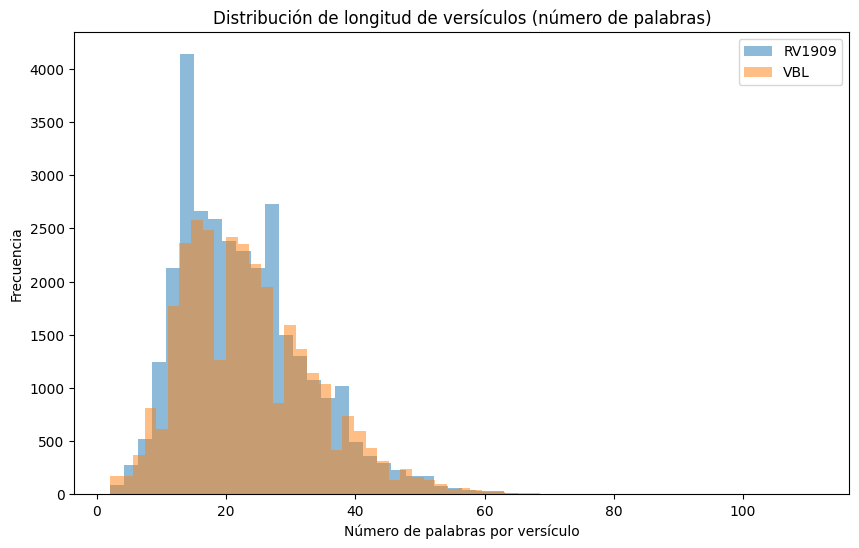


=== Top 10 libros con mayor número de versículos ===


,count
book_es,
Salmos,2461
Génesis,1532
Jeremías,1363
Isaías,1290
Números,1271
Ezequiel,1268
Éxodo,1208
Lucas,1149
Mateo,1068


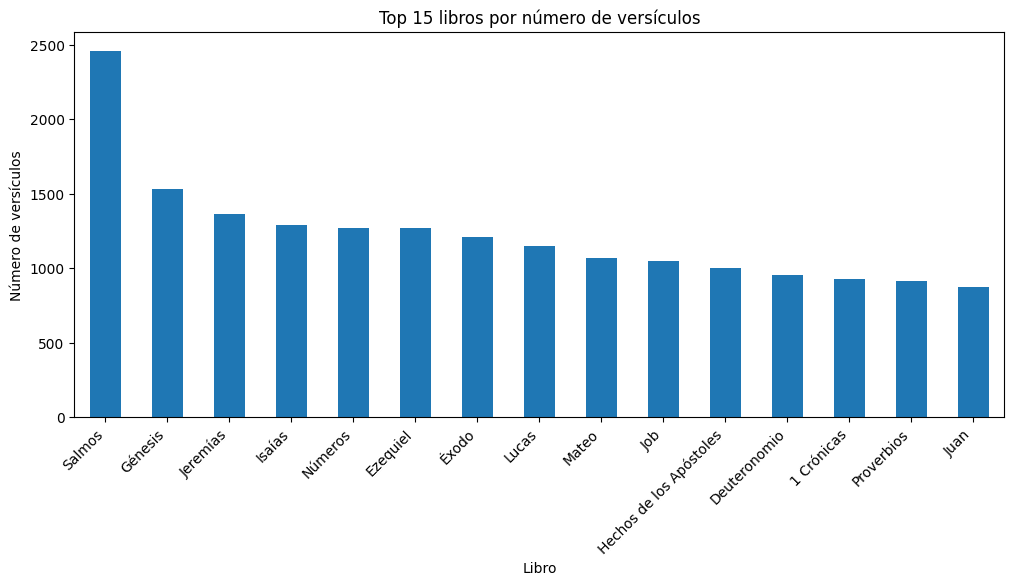


=== Estadísticas léxicas globales ===
Total de tokens RV1909: 700,391
Total de tokens VBL: 723,369
Vocabulario único RV1909: 28,074
Vocabulario único VBL: 27,290

=== Top 20 palabras más frecuentes (RV1909) ===


,Palabra,Frecuencia
0,y,48182
1,de,44472
2,que,19744
3,á,19226
4,la,18639
5,el,17287
6,los,16486
7,en,15701
8,no,8216
9,su,7803



=== Top 20 palabras más frecuentes (VBL) ===


,Palabra,Frecuencia
0,de,35743
1,y,27221
2,que,25899
3,el,21885
4,a,21496
5,la,17288
6,los,16861
7,en,13672
8,se,8772
9,no,8579


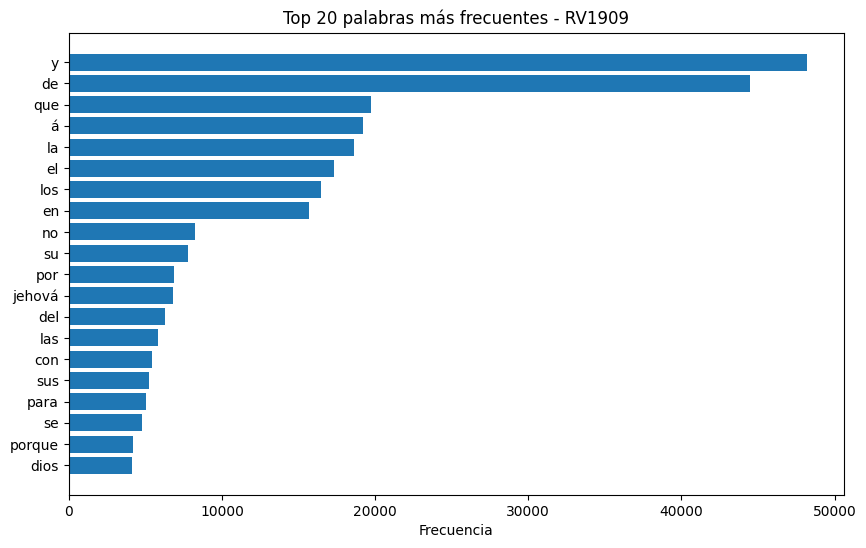

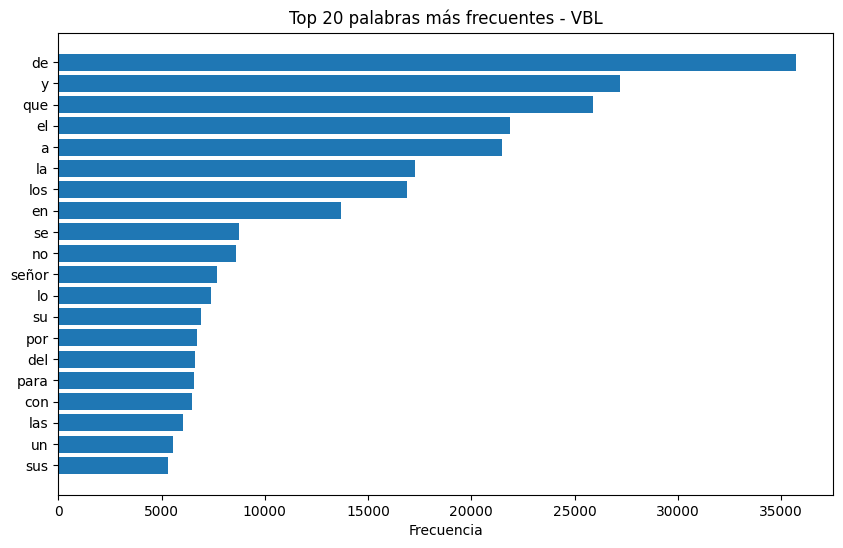


=== Estadísticas del número de capítulo ===
count    30938.000000
mean        20.673993
std         23.445823
min          1.000000
25%          6.000000
50%         14.000000
75%         26.000000
max        150.000000
Name: chapter, dtype: float64


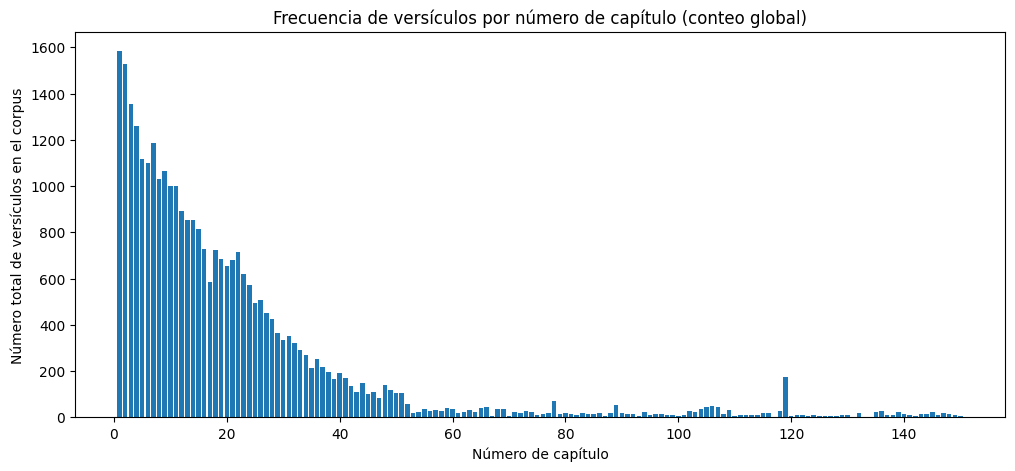

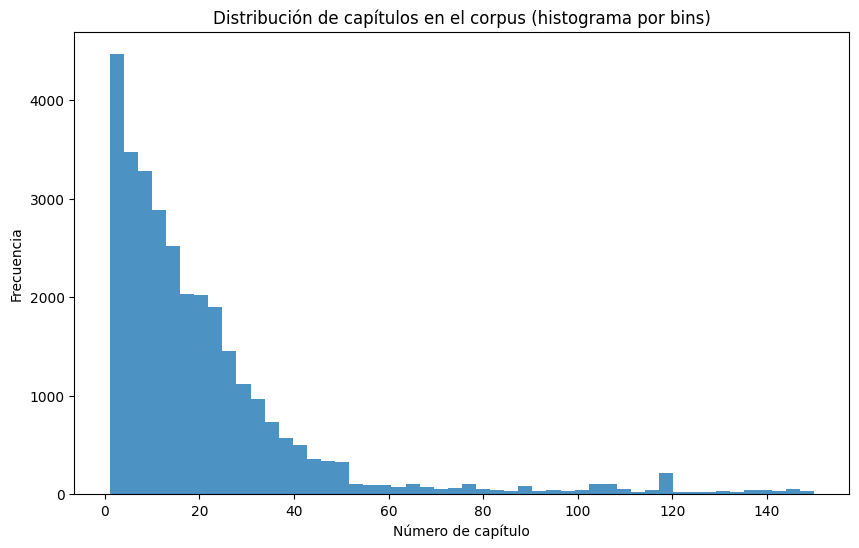


=== Top 10 números de capítulo con mayor número de versículos ===


,count,count
0,1,1586
1,2,1526
2,3,1356
3,4,1258
4,7,1184
5,5,1118
6,6,1098
7,9,1067
8,8,1032
9,11,1000



Análisis univariante completado.


In [5]:
# ============================
# 3.2 - Análisis Univariante del Corpus Bíblico
# ============================

# ----------------------------
# Configuración general de gráficos
# ----------------------------
plt.rcParams["figure.figsize"] = (10, 6)

# ----------------------------
# Carga del dataset estructurado y alineado
# ----------------------------
BASE_PATH = "/content/drive/MyDrive/Maestría ITESM/LUMINA - Proyecto Integrador/Avance 1 - EDA (Steven)"
DATA_PATH = f"{BASE_PATH}/data/processed/bible_structured.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset cargado correctamente")
display(df.head())

print("\n=== Dimensión del dataset alineado ===")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

# ----------------------------
# Subconjunto textual para análisis lingüístico
# (Ya no debería haber NaN, es solo para corroborar)
# ----------------------------
df_textual = df.dropna(subset=["text_rv1909", "text_vbl"]).copy()

print("\n=== Dataset textual válido para análisis lingüístico ===")
print(f"Filas: {df_textual.shape[0]:,}")

# ============================================================
# 1) Distribución de longitud de versículos (tokens tipo palabra)
# ============================================================

def word_count(s):
    """
    Cuenta palabras de forma robusta:
    - Convierte a string si es necesario
    - Separa por espacios
    """
    return len(str(s).split())

# Cálculo de longitudes por versión
df_textual["wc_rv1909"] = df_textual["text_rv1909"].apply(word_count)
df_textual["wc_vbl"]    = df_textual["text_vbl"].apply(word_count)

print("\n=== Estadísticas descriptivas - Longitud de versículos ===")
print("\nRV1909:")
print(df_textual["wc_rv1909"].describe())

print("\nVBL:")
print(df_textual["wc_vbl"].describe())

# Histograma comparativo
plt.figure()
plt.hist(df_textual["wc_rv1909"], bins=50, alpha=0.5, label="RV1909")
plt.hist(df_textual["wc_vbl"], bins=50, alpha=0.5, label="VBL")
plt.title("Distribución de longitud de versículos (número de palabras)")
plt.xlabel("Número de palabras por versículo")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

# ============================================================
# 2) Distribución de versículos por libro
# ============================================================

verses_per_book = (
    df_textual["book_es"]
    .value_counts()
    .sort_values(ascending=False)
)

print("\n=== Top 10 libros con mayor número de versículos ===")
display(verses_per_book.head(10))

# Gráfico de barras (Top 15)
plt.figure(figsize=(12, 5))
verses_per_book.head(15).plot(kind="bar")
plt.title("Top 15 libros por número de versículos")
plt.xlabel("Libro")
plt.ylabel("Número de versículos")
plt.xticks(rotation=45, ha="right")
plt.show()

# ============================================================
# 3) Estadísticas léxicas básicas (tokenización)
# ============================================================

def tokenize(text):
    """
    Tokeniza el texto:
    - Convierte a minúsculas
    - Elimina signos de puntuación
    - Conserva acentos y caracteres del español
    """
    text = text.lower()
    text = re.sub(r"[^\w\sáéíóúñü]", "", text)
    return text.split()

# Tokenización y expansión en columnas largas
tokens_rv1909 = df_textual["text_rv1909"].apply(tokenize).explode()
tokens_vbl    = df_textual["text_vbl"].apply(tokenize).explode()

print("\n=== Estadísticas léxicas globales ===")
print(f"Total de tokens RV1909: {len(tokens_rv1909):,}")
print(f"Total de tokens VBL: {len(tokens_vbl):,}")
print(f"Vocabulario único RV1909: {tokens_rv1909.nunique():,}")
print(f"Vocabulario único VBL: {tokens_vbl.nunique():,}")

# ============================================================
# 4) Palabras más frecuentes
# ============================================================

top_rv1909 = Counter(tokens_rv1909).most_common(20)
top_vbl    = Counter(tokens_vbl).most_common(20)

top_rv1909_df = pd.DataFrame(top_rv1909, columns=["Palabra", "Frecuencia"])
top_vbl_df    = pd.DataFrame(top_vbl, columns=["Palabra", "Frecuencia"])

print("\n=== Top 20 palabras más frecuentes (RV1909) ===")
display(top_rv1909_df)

print("\n=== Top 20 palabras más frecuentes (VBL) ===")
display(top_vbl_df)

# Visualización horizontal para mejor lectura
plt.figure()
plt.barh(top_rv1909_df["Palabra"][::-1], top_rv1909_df["Frecuencia"][::-1])
plt.title("Top 20 palabras más frecuentes - RV1909")
plt.xlabel("Frecuencia")
plt.show()

plt.figure()
plt.barh(top_vbl_df["Palabra"][::-1], top_vbl_df["Frecuencia"][::-1])
plt.title("Top 20 palabras más frecuentes - VBL")
plt.xlabel("Frecuencia")
plt.show()

# ============================================================
# 5) Distribución por número de capítulo
# ============================================================

print("\n=== Estadísticas del número de capítulo ===")
print(df_textual["chapter"].describe())

# Frecuencia discreta exacta por capítulo
chapter_counts = df_textual["chapter"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.bar(chapter_counts.index, chapter_counts.values)
plt.title("Frecuencia de versículos por número de capítulo (conteo global)")
plt.xlabel("Número de capítulo")
plt.ylabel("Número total de versículos en el corpus")
plt.show()

# Histograma alternativo (agrupado en bins)
plt.figure()
plt.hist(df_textual["chapter"], bins=50, alpha=0.8)
plt.title("Distribución de capítulos en el corpus (histograma por bins)")
plt.xlabel("Número de capítulo")
plt.ylabel("Frecuencia")
plt.show()

# Identificación de picos estructurales
print("\n=== Top 10 números de capítulo con mayor número de versículos ===")
display(
    chapter_counts
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={"index": "chapter", "chapter": "count"})
)

print("\nAnálisis univariante completado.")

## Sobre el análisis univariante

El anterior análisis revela patrones estructurales y lingüísticos con implicaciones directas para el diseño del sistema LUMINA y su arquitectura de recuperación semántica.

En términos de **longitud textual**, ambas traducciones presentan distribuciones asimétricas con cola derecha, donde la mayoría de los versículos se concentran en un rango intermedio (entre aproximadamente 15 y 30 palabras), pero existen observaciones extremas que superan las 90 e incluso 100 palabras. Estos valores atípicos confirman que el corpus no es homogéneo en densidad semántica y que una estrategia de segmentación uniforme (por ejemplo, chunking fijo por número de versículos) podría generar bloques de información con cargas conceptuales muy dispares.

Desde la perspectiva **léxica**, se observa una alta frecuencia de palabras funcionales y conectores gramaticales en ambas versiones, lo que sugiere la necesidad de normalización adicional (stopwords, lematización o ponderación por TF-IDF) en etapas posteriores si se desea enfatizar términos con mayor carga semántica para tareas de recuperación o generación de respuestas.

La distribución de versículos por libro confirma un **desequilibrio estructural significativo**, donde textos como Salmos, Génesis, Isaías y Jeremías concentran una proporción sustancial del corpus. Este sesgo implica que, sin mecanismos de control o filtrado, los sistemas de recuperación semántica tenderán a favorecer estos libros en detrimento de otros más breves, afectando la diversidad de respuestas generadas por el sistema.

Finalmente, la frecuencia global por número de capítulo muestra que ciertos capítulos de alta numeración presentan picos inesperados de versículos, lo que se explica por la presencia de capítulos excepcionalmente largos en libros específicos (por ejemplo, Salmos). Este patrón refuerza la idea de que la estructura canónica introduce una variabilidad jerárquica que debe ser considerada explícitamente en el diseño de índices, ventanas de contexto y estrategias de partición del corpus.

En conjunto, estos hallazgos justifican la necesidad de un preprocesamiento adaptativo, sensible tanto a la longitud como a la estructura jerárquica del texto, como base para una arquitectura RAG robusta, equitativa en cobertura y eficiente en recuperación semántica.

---

> “*De la abundancia del corazón habla la boca.*”
>
> — Lucas 6:45

---

## **3.3 Cardinalidad y complejidad categórica**

En esta sección se analiza la **diversidad estructural y léxica del corpus** desde la perspectiva de cardinalidad, entendida como el número de categorías y valores únicos presentes en las variables del dataset y en el vocabulario implícito del texto bíblico.

El objetivo es evaluar:

- La cardinalidad de las variables categóricas estructurales (libros, capítulos y referencias).
- La diversidad léxica en ambas traducciones, medida a través del tamaño del vocabulario y su distribución de frecuencias.
- La relación entre frecuencia y relevancia semántica de los términos, identificando patrones de concentración léxica y colas largas (long-tail).

Este análisis permite estimar la **complejidad del espacio semántico** que deberá ser representado por los embeddings y gestionado por los mecanismos de indexación y recuperación. Una alta cardinalidad léxica implica mayores requerimientos de representación vectorial, mientras que una concentración excesiva en pocos términos puede introducir sesgos en los resultados de búsqueda y generación.

Los hallazgos de esta sección servirán como base para justificar decisiones sobre:
- Normalización del vocabulario (stopwords, lematización, subword tokenization).
- Tamaño y tipo de embeddings.
- Estrategias de filtrado y ponderación en el motor de recuperación semántica de LUMINA.

<>:111: SyntaxWarning: invalid escape sequence '\w'
<>:111: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipython-input-1791486776.py:111: SyntaxWarning: invalid escape sequence '\w'
  Nota: \w incluye letras/dígitos/underscore; aquí conservamos acentos con el rango explícito.


Dataset cargado correctamente
Filas: 30938 | Columnas: 7


,ref,book,chapter,verse,text_rv1909,text_vbl,book_es
0,GEN 1:1,GEN,1,1,EN el principio crió Dios los cielos y la tierra.,"En el principio, Dios creó los cielos y la tie...",Génesis
1,GEN 1:2,GEN,1,2,"Y la tierra estaba desordenada y vacía, y las ...",La tierra carecía de forma y estaba vacía; la ...,Génesis
2,GEN 1:3,GEN,1,3,Y dijo Dios: Sea la luz: y fué la luz.,Y Dios dijo: “¡Que haya luz!” y hubo luz.,Génesis



=== Cardinalidad estructural ===
Libros únicos: 66
Números de capítulo únicos (global): 150
Referencias únicas (ref): 30938
Capítulos únicos (book+chapter): 1188
Versículos únicos (book+chapter+verse): 30938

Top 10 libros con MÁS capítulos:


,Libro,Capítulos
0,Salmos,150
1,Isaías,66
2,Jeremías,52
3,Génesis,50
4,Ezequiel,48
5,Job,42
6,Éxodo,40
7,2 Crónicas,36
8,Números,36
9,Deuteronomio,34


...

,Libro,Capítulos
0,2 Pedro,3
1,Malaquías,3
2,Tito,3
3,Sofonías,3
4,Hageo,2
5,Abdías,1
6,Filemón,1
7,2 Juan,1
8,3 Juan,1
9,Judas,1



=== Distribución de versículos por libro ===
Top 10 libros con más versículos:


,book_es,Versículos
0,Salmos,2461
1,Génesis,1532
2,Jeremías,1363
3,Isaías,1290
4,Números,1271
5,Ezequiel,1268
6,Éxodo,1208
7,Lucas,1149
8,Mateo,1068
9,Job,1053



Top 10 libros con menos versículos:


,book_es,Versículos
0,Jonás,47
1,2 Tesalonicenses,47
2,Tito,46
3,Nahúm,46
4,Hageo,38
5,Filemón,25
6,Judas,25
7,Abdías,21
8,3 Juan,14
9,2 Juan,13


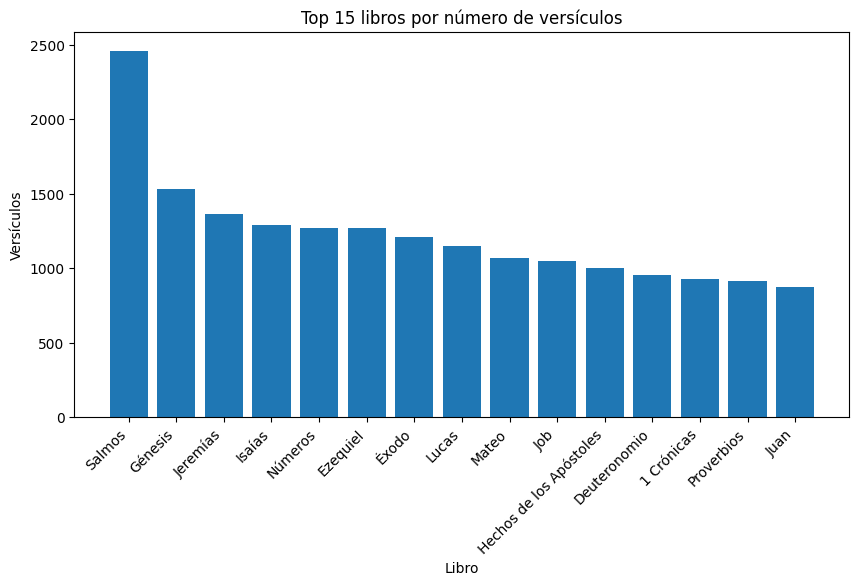

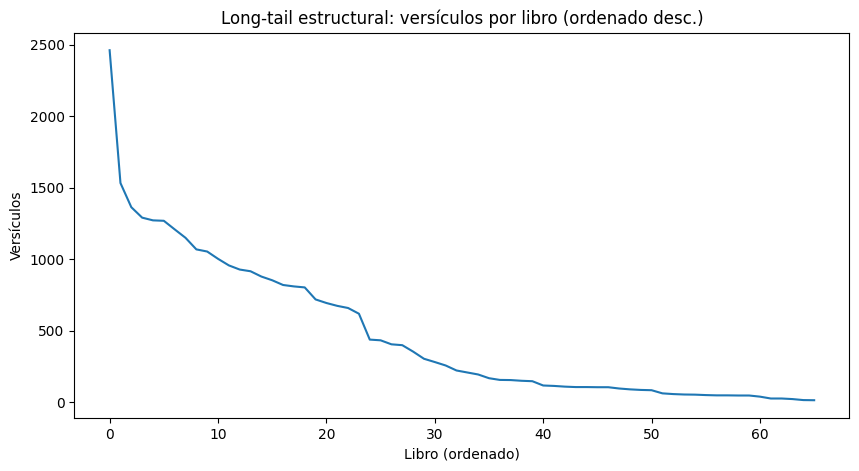

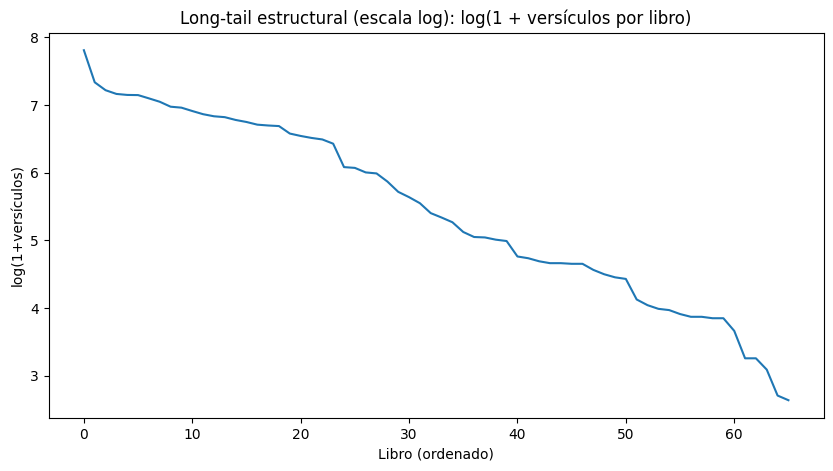


=== Diversidad léxica (tokens/vocabulario) ===
RV1909 -> Tokens totales: 700,391 | Vocabulario único (types): 28,074
VBL    -> Tokens totales: 723,369 | Vocabulario único (types): 27,290

=== TTR (Type-Token Ratio) ===
RV1909 TTR: 0.040083
VBL    TTR: 0.037726

=== MATTR aprox (ventanas de 5000 tokens) ===
RV1909 MATTR: 0.224119
VBL    MATTR: 0.245453


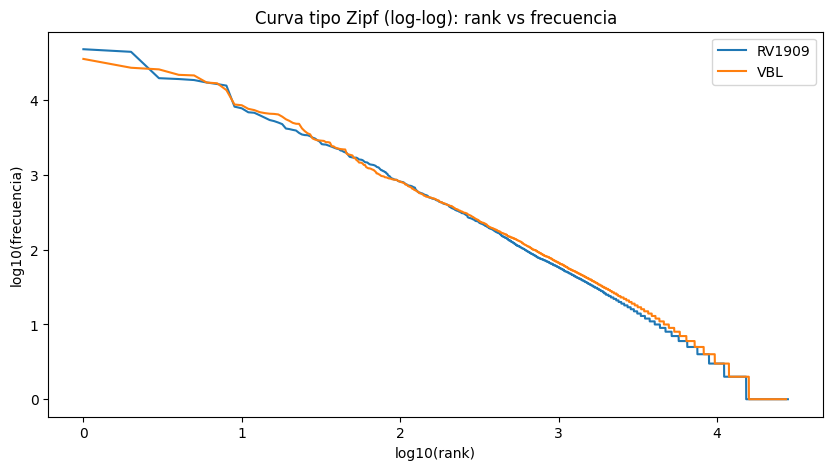


=== Hapax legomena (palabras que aparecen 1 sola vez) ===
RV1909 -> hapax: 12,792 (45.57% del vocabulario)
VBL    -> hapax: 11,395 (41.76% del vocabulario)

=== Cobertura acumulada por Top-K términos ===


,K,RV1909_cobertura,VBL_cobertura
0,10,0.308051,0.272912
1,50,0.498335,0.481402
2,100,0.584338,0.556626
3,500,0.757635,0.728910
4,1000,0.817174,0.796292
5,5000,0.931091,0.926935


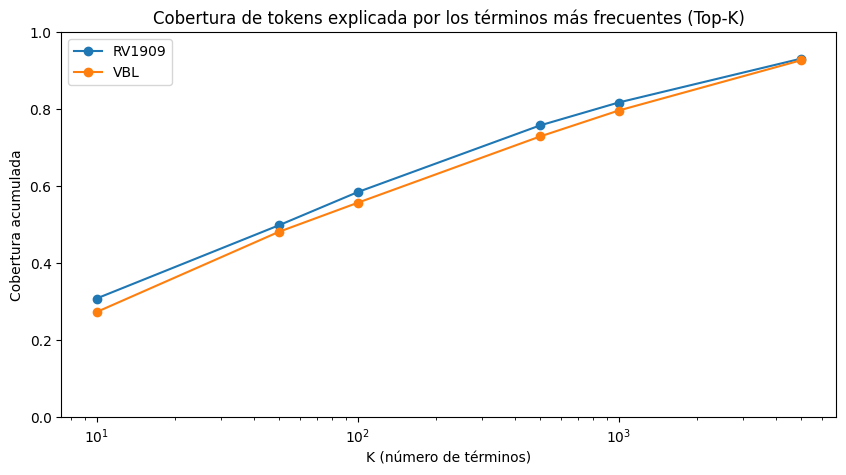


=== Comparación de vocabulario entre versiones ===
Vocab RV1909: 28,074
Vocab VBL   : 27,290
Intersección: 12,396
Solo RV1909 : 15,678
Solo VBL    : 14,894
Jaccard(Vocabs): 0.2885

Ejemplos (10) de términos solo en RV1909:
['aaronitas', 'abaddon', 'abagtha', 'abajada', 'abajadas', 'abajado', 'abajó', 'abanderado', 'abastecer', 'abastecerás']

Ejemplos (10) de términos solo en VBL:
['10', '100', '1000', '10000', '100000', '1000000', '1017', '105', '1052', '108100']

=== Implicaciones técnicas (resumen) ===
- Alta cardinalidad léxica + long-tail -> embeddings y recuperación deberán manejar vocabulario raro (hapax/low-freq).
- Cobertura Top-K suele ser baja para K pequeños -> stopwords dominan tokens; conviene normalización/ponderación (TF-IDF/BM25 o filtros).
- Diferencias de vocabulario y Jaccard < 1 -> traducciones inducen espacios semánticos distintos; útil mantener metadatos de versión.
- Long-tail estructural (libros) -> riesgo de sesgo en retrieval hacia libros largos (Salmos, pro

In [6]:
# ============================
# 3.3 - Cardinalidad y complejidad categórica
# ============================

# ----------------------------
# 1) Carga del dataset alineado
# ----------------------------

BASE_PATH = "/content/drive/MyDrive/Maestría ITESM/LUMINA - Proyecto Integrador/Avance 1 - EDA (Steven)"
DATA_PATH = f"{BASE_PATH}/data/processed/bible_structured.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset cargado correctamente")
print("Filas:", len(df), "| Columnas:", df.shape[1])
display(df.head(3))

# Verificación rápida de columnas esperadas (por si acaso)
required_cols = {"ref", "book", "book_es", "chapter", "verse", "text_rv1909", "text_vbl"}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"Faltan columnas requeridas: {missing_cols}")

# ----------------------------
# 2) Cardinalidad estructural
# ----------------------------

print("\n=== Cardinalidad estructural ===")

n_books = df["book_es"].nunique()
n_chapters_global = df["chapter"].nunique()
n_refs = df["ref"].nunique()

# Cardinalidad por libro: cuántos capítulos únicos tiene cada libro
chapters_per_book = df.groupby("book_es")["chapter"].nunique().sort_values(ascending=False)

# Cardinalidad "capítulo real" (book + chapter)
df["book_chapter_id"] = df["book"].astype(str) + "_" + df["chapter"].astype(str)
n_book_chapters = df["book_chapter_id"].nunique()

# Cardinalidad "versículo real" (book + chapter + verse)
df["book_chapter_verse_id"] = (
    df["book"].astype(str) + "_" +
    df["chapter"].astype(str) + "_" +
    df["verse"].astype(str)
)
n_bcv = df["book_chapter_verse_id"].nunique()

print(f"Libros únicos: {n_books}")
print(f"Números de capítulo únicos (global): {n_chapters_global}")
print(f"Referencias únicas (ref): {n_refs}")
print(f"Capítulos únicos (book+chapter): {n_book_chapters}")
print(f"Versículos únicos (book+chapter+verse): {n_bcv}")

# Top/bottom libros por cantidad de capítulos
print("\nTop 10 libros con MÁS capítulos:")
display(chapters_per_book.head(10).reset_index().rename(columns={"book_es":"Libro", "chapter":"Capítulos"}))

print("\nTop 10 libros con MENOS capítulos:")
display(chapters_per_book.tail(10).reset_index().rename(columns={"book_es":"Libro", "chapter":"Capítulos"}))

# ----------------------------
# 3) Distribución de cardinalidad por libro (versículos por libro)
# ----------------------------

verses_per_book = df["book_es"].value_counts()

print("\n=== Distribución de versículos por libro ===")
print("Top 10 libros con más versículos:")
display(verses_per_book.head(10).reset_index().rename(columns={"index":"Libro", "count":"Versículos"}))

print("\nTop 10 libros con menos versículos:")
display(verses_per_book.tail(10).reset_index().rename(columns={"index":"Libro", "count":"Versículos"}))

# Gráfico: barras Top 15 por versículos
plt.figure(figsize=(10, 5))
top15 = verses_per_book.head(15)
plt.bar(top15.index, top15.values)
plt.title("Top 15 libros por número de versículos")
plt.xlabel("Libro")
plt.ylabel("Versículos")
plt.xticks(rotation=45, ha="right")
plt.show()

# Gráfico: distribución (log) de versículos por libro para ver el long-tail estructural
plt.figure(figsize=(10, 5))
sorted_counts = verses_per_book.sort_values(ascending=False).values
plt.plot(sorted_counts)
plt.title("Long-tail estructural: versículos por libro (ordenado desc.)")
plt.xlabel("Libro (ordenado)")
plt.ylabel("Versículos")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(np.log1p(sorted_counts))
plt.title("Long-tail estructural (escala log): log(1 + versículos por libro)")
plt.xlabel("Libro (ordenado)")
plt.ylabel("log(1+versículos)")
plt.show()

# ----------------------------
# 4) Tokenización y vocabulario (diversidad léxica)
# ----------------------------

def tokenize(text: str):
    """
    Tokenización simple y reproducible:
    - minúsculas
    - elimina puntuación (conserva letras con acento)
    - separa por espacios
    Nota: \w incluye letras/dígitos/underscore; aquí conservamos acentos con el rango explícito.
    """
    text = str(text).lower()
    text = re.sub(r"[^\w\sáéíóúñü]", "", text)
    tokens = text.split()
    return tokens

# Tokenizamos ambas traducciones
tokens_rv = df["text_rv1909"].apply(tokenize).explode()
tokens_vb = df["text_vbl"].apply(tokenize).explode()

# Conteos básicos
N_rv = len(tokens_rv)
N_vb = len(tokens_vb)

V_rv = tokens_rv.nunique()
V_vb = tokens_vb.nunique()

print("\n=== Diversidad léxica (tokens/vocabulario) ===")
print(f"RV1909 -> Tokens totales: {N_rv:,} | Vocabulario único (types): {V_rv:,}")
print(f"VBL    -> Tokens totales: {N_vb:,} | Vocabulario único (types): {V_vb:,}")

# Type-Token Ratio (TTR) (ojo: sensible a tamaño, se usa como referencia rápida)
ttr_rv = V_rv / N_rv
ttr_vb = V_vb / N_vb

print("\n=== TTR (Type-Token Ratio) ===")
print(f"RV1909 TTR: {ttr_rv:.6f}")
print(f"VBL    TTR: {ttr_vb:.6f}")

# ----------------------------
# 5) Métrica más estable: Moving-Average TTR (MATTR) aproximada
# ----------------------------

def mattr(tokens, window=5000, step=5000):
    """
    Aproximación de MATTR:
    - calcula TTR en ventanas deslizantes de tamaño fijo
    - promedia los TTR de cada ventana
    Para eficiencia, usamos step = window (no solapadas).
    """
    tokens = list(tokens)
    if len(tokens) < window:
        return np.nan
    ttrs = []
    for i in range(0, len(tokens) - window + 1, step):
        window_tokens = tokens[i:i+window]
        ttrs.append(len(set(window_tokens)) / len(window_tokens))
    return float(np.mean(ttrs)) if ttrs else np.nan

mattr_rv = mattr(tokens_rv, window=5000, step=5000)
mattr_vb = mattr(tokens_vb, window=5000, step=5000)

print("\n=== MATTR aprox (ventanas de 5000 tokens) ===")
print(f"RV1909 MATTR: {mattr_rv:.6f}")
print(f"VBL    MATTR: {mattr_vb:.6f}")

# ----------------------------
# 6) Distribución de frecuencias (Zipf / long-tail léxico)
# ----------------------------

freq_rv = Counter(tokens_rv)
freq_vb = Counter(tokens_vb)

# Ordenamos por frecuencia desc (rank-frequency)
rv_sorted = np.array(sorted(freq_rv.values(), reverse=True))
vb_sorted = np.array(sorted(freq_vb.values(), reverse=True))

# Curva Zipf (rank vs freq) en escala log-log
plt.figure(figsize=(10, 5))
plt.plot(np.log10(np.arange(1, len(rv_sorted)+1)), np.log10(rv_sorted), label="RV1909")
plt.plot(np.log10(np.arange(1, len(vb_sorted)+1)), np.log10(vb_sorted), label="VBL")
plt.title("Curva tipo Zipf (log-log): rank vs frecuencia")
plt.xlabel("log10(rank)")
plt.ylabel("log10(frecuencia)")
plt.legend()
plt.show()

# ----------------------------
# 7) Hapax legomena y rareza léxica
# ----------------------------

hapax_rv = sum(1 for w, c in freq_rv.items() if c == 1)
hapax_vb = sum(1 for w, c in freq_vb.items() if c == 1)

pct_hapax_rv = hapax_rv / V_rv
pct_hapax_vb = hapax_vb / V_vb

print("\n=== Hapax legomena (palabras que aparecen 1 sola vez) ===")
print(f"RV1909 -> hapax: {hapax_rv:,} ({pct_hapax_rv:.2%} del vocabulario)")
print(f"VBL    -> hapax: {hapax_vb:,} ({pct_hapax_vb:.2%} del vocabulario)")

# ----------------------------
# 8) Cobertura top-K (qué tanto explica el vocabulario frecuente)
# ----------------------------

def topk_coverage(counter: Counter, K_list=(10, 50, 100, 500, 1000, 5000)):
    total = sum(counter.values())
    most_common = counter.most_common(max(K_list))
    freqs = np.array([c for _, c in most_common])
    cum = np.cumsum(freqs)
    cov = {}
    for K in K_list:
        cov[K] = float(cum[K-1] / total) if K <= len(cum) else 1.0
    return cov

cov_rv = topk_coverage(freq_rv)
cov_vb = topk_coverage(freq_vb)

print("\n=== Cobertura acumulada por Top-K términos ===")
cov_df = pd.DataFrame({
    "K": list(cov_rv.keys()),
    "RV1909_cobertura": list(cov_rv.values()),
    "VBL_cobertura": list(cov_vb.values())
})
display(cov_df)

# Visualización cobertura
plt.figure(figsize=(10, 5))
plt.plot(cov_df["K"], cov_df["RV1909_cobertura"], marker="o", label="RV1909")
plt.plot(cov_df["K"], cov_df["VBL_cobertura"], marker="o", label="VBL")
plt.title("Cobertura de tokens explicada por los términos más frecuentes (Top-K)")
plt.xlabel("K (número de términos)")
plt.ylabel("Cobertura acumulada")
plt.xscale("log")
plt.ylim(0, 1)
plt.legend()
plt.show()

# ----------------------------
# 9) Intersección y diferencia de vocabularios entre traducciones
# ----------------------------

vocab_rv = set(freq_rv.keys())
vocab_vb = set(freq_vb.keys())

intersection = vocab_rv.intersection(vocab_vb)
only_rv = vocab_rv - vocab_vb
only_vb = vocab_vb - vocab_rv

jaccard = len(intersection) / len(vocab_rv.union(vocab_vb))

print("\n=== Comparación de vocabulario entre versiones ===")
print(f"Vocab RV1909: {len(vocab_rv):,}")
print(f"Vocab VBL   : {len(vocab_vb):,}")
print(f"Intersección: {len(intersection):,}")
print(f"Solo RV1909 : {len(only_rv):,}")
print(f"Solo VBL    : {len(only_vb):,}")
print(f"Jaccard(Vocabs): {jaccard:.4f}")

# Muestra de términos exclusivos (solo para inspección cualitativa)
print("\nEjemplos (10) de términos solo en RV1909:")
print(list(sorted(only_rv))[:10])

print("\nEjemplos (10) de términos solo en VBL:")
print(list(sorted(only_vb))[:10])

# ----------------------------
# 10) Implicaciones directas (prints cortos para discutir)
# ----------------------------

print("\n=== Implicaciones técnicas (resumen) ===")
print("- Alta cardinalidad léxica + long-tail -> embeddings y recuperación deberán manejar vocabulario raro (hapax/low-freq).")
print("- Cobertura Top-K suele ser baja para K pequeños -> stopwords dominan tokens; conviene normalización/ponderación (TF-IDF/BM25 o filtros).")
print("- Diferencias de vocabulario y Jaccard < 1 -> traducciones inducen espacios semánticos distintos; útil mantener metadatos de versión.")
print("- Long-tail estructural (libros) -> riesgo de sesgo en retrieval hacia libros largos (Salmos, profetas).")

print("\nSección 3.3 completada.")

## Sobre la cardinalidad y complejidad categórica

El análisis de cardinalidad y complejidad categórica del corpus bíblico confirma que el dataset presenta una estructura altamente jerárquica y estadísticamente desequilibrada, tanto en su dimensión estructural como en su dimensión léxica.

En el plano estructural, se identificó un espacio de referencia claramente definido por 66 libros, 1,188 combinaciones únicas de libro-capítulo y 30,938 versículos únicos, lo que proporciona una base sólida para el diseño de identificadores compuestos, esquemas de filtrado semántico y mecanismos de recuperación jerárquica. Sin embargo, la distribución de versículos por libro revela un patrón de **long-tail estructural pronunciado**, donde un conjunto reducido de libros concentra una fracción significativa del corpus, mientras que la mayoría de los libros presentan una cobertura mínima.

En el plano lingüístico, los valores de diversidad léxica (TTR bajo y MATTR elevado) confirman que el corpus combina alta saturación global con riqueza semántica local. La elevada proporción de hapax legomena (más del 40% del vocabulario en ambas versiones) evidencia la presencia de una cola léxica extensa, compuesta por términos raros, nombres propios, formas arcaicas y expresiones altamente contextuales. Este comportamiento introduce un desafío directo para los modelos de recuperación y representación semántica, ya que la señal informativa relevante se encuentra mayormente en regiones de baja frecuencia estadística.

La baja similitud léxica entre versiones (índice de Jaccard ≈ 0.29) demuestra que las traducciones no solo difieren en estilo, sino que inducen **espacios semánticos parcialmente disjuntos**, lo que refuerza la necesidad de tratar la versión textual como un metadato crítico dentro del sistema LUMINA. Esta observación respalda arquitecturas con embeddings separados o condicionados por traducción, así como estrategias de recuperación multiversión.

Finalmente, la presencia simultánea de un long-tail estructural por libros y un long-tail léxico por vocabulario establece un riesgo claro de **sesgo semántico por dominancia estructural**, en el cual los libros extensos y los términos de alta frecuencia tienden a dominar los resultados de recuperación. Este hallazgo justifica el uso de técnicas de normalización, re-ranking estratificado y ponderación por frecuencia en la arquitectura RAG, con el objetivo de preservar la representatividad semántica de los libros cortos y de los conceptos raros.

Estos resultados consolidan la transición hacia un análisis bivariado, donde se explorarán explícitamente las relaciones entre estructura canónica y propiedades lingüísticas, así como su impacto en la calidad, equidad y robustez del sistema de recuperación y generación de conocimiento en LUMINA.

---

> “*El corazón del entendido adquiere sabiduría; y el oído de los sabios busca la ciencia.*”
>
> — Proverbios 18:15 (RV1909)

---

## **3.4 Análisis bivariado y relaciones estructurales**

En esta sección se exploran las relaciones entre las dimensiones estructurales del corpus bíblico (libro, capítulo y versículo) y sus propiedades lingüísticas, con el objetivo de identificar patrones de dependencia, concentración semántica y variabilidad textual entre diferentes niveles de la jerarquía canónica.

A partir de los hallazgos de la Sección 3.3, donde se evidenció la existencia de un long-tail tanto estructural como léxico, este análisis profundiza en cómo la longitud de los versículos, la densidad léxica y la diversidad semántica se distribuyen entre libros y capítulos. Este enfoque permite evaluar si ciertos libros o secciones presentan estilos lingüísticos sistemáticamente más densos, más variables o más informativos que otros.

Los resultados de esta sección son fundamentales para el diseño de estrategias de segmentación (chunking), indexación jerárquica y re-ranking semántico dentro de la arquitectura RAG de LUMINA, ya que permiten alinear la estructura canónica del texto con la lógica de recuperación y generación de respuestas del sistema.

Dataset cargado correctamente
Filas: 30938 | Columnas: 7


,ref,book,chapter,verse,text_rv1909,text_vbl,book_es
0,GEN 1:1,GEN,1,1,EN el principio crió Dios los cielos y la tierra.,"En el principio, Dios creó los cielos y la tie...",Génesis
1,GEN 1:2,GEN,1,2,"Y la tierra estaba desordenada y vacía, y las ...",La tierra carecía de forma y estaba vacía; la ...,Génesis
2,GEN 1:3,GEN,1,3,Y dijo Dios: Sea la luz: y fué la luz.,Y Dios dijo: “¡Que haya luz!” y hubo luz.,Génesis
3,GEN 1:4,GEN,1,4,Y vió Dios que la luz era buena: y apartó Dios...,"Dios vio que la luz era buena, y separó a la l...",Génesis
4,GEN 1:5,GEN,1,5,"Y llamó Dios á la luz Día, y á las tinieblas l...",Entonces Dios llamó a la luz “día” y a la oscu...,Génesis



=== Estadísticas bivariadas por libro (Top 15 por tamaño) ===


,versos,wc_rv1909_mean,wc_vbl_mean,wc_diff_mean
book_es,,,,
Salmos,2461,15.29,16.45,3.28
Génesis,1532,22.79,23.13,3.75
Jeremías,1363,27.15,28.59,4.54
Isaías,1290,24.40,26.54,4.38
Números,1271,22.20,22.03,4.14
Ezequiel,1268,26.69,27.07,4.07
Éxodo,1208,23.59,23.23,3.77
Lucas,1149,19.82,21.19,3.53
Mateo,1068,19.86,21.52,3.48


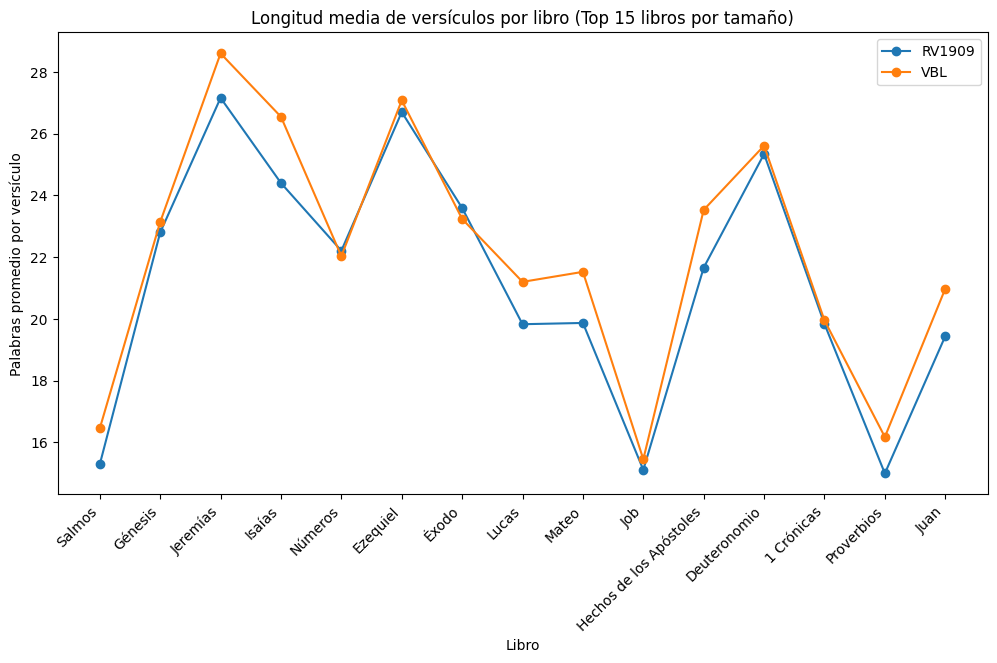

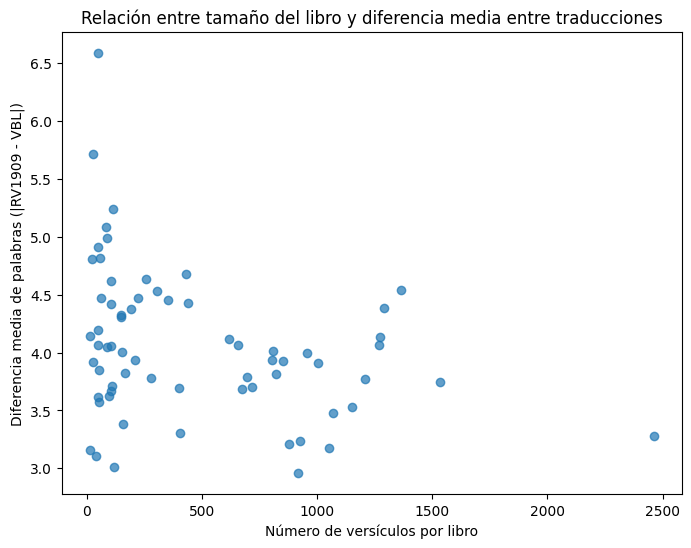


=== Libros con mayor variabilidad en longitud de versículos ===


,wc_rv1909_std,wc_vbl_std
book_es,,
Nehemías,13.42,14.54
Esdras,13.22,14.14
Ester,13.02,13.98
Josué,12.58,12.45
Daniel,11.93,11.46
2 Crónicas,11.16,11.48
2 Samuel,10.98,11.01
1 Crónicas,10.90,10.89
2 Reyes,10.83,10.80



=== Ejemplo de estadísticas por capítulo (libros largos) ===


,book_es,chapter,versos,wc_rv1909_mean,wc_vbl_mean
0,1 Crónicas,1,54,11.43,11.09
1,1 Crónicas,2,55,14.85,15.95
2,1 Crónicas,3,24,13.88,13.33
3,1 Crónicas,4,43,19.09,18.00
4,1 Crónicas,5,26,23.92,23.42
5,1 Crónicas,6,66,14.86,13.98
6,1 Crónicas,7,40,18.25,16.82
7,1 Crónicas,8,40,10.95,10.62
8,1 Crónicas,9,44,20.20,19.89
9,1 Crónicas,10,14,24.57,23.93



=== Matriz de correlación global ===


,chapter,wc_rv1909,wc_vbl,wc_diff
chapter,1.000,-0.141,-0.132,-0.036
wc_rv1909,-0.141,1.000,0.870,0.260
wc_vbl,-0.132,0.870,1.000,0.324
wc_diff,-0.036,0.260,0.324,1.000


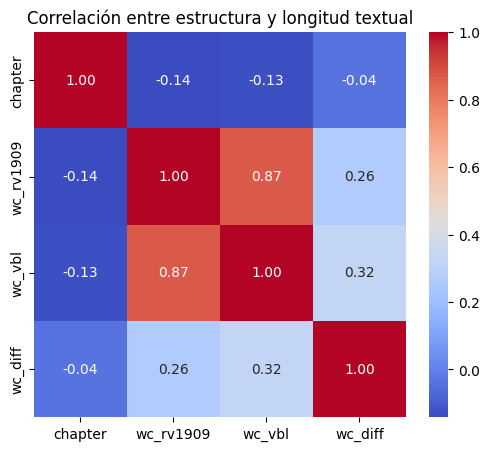


=== Interpretación preliminar ===
- Longitudes medias por libro permiten detectar estilos narrativos vs poéticos.
- La relación entre tamaño del libro y diferencia entre traducciones indica si los libros largos tienden a amplificar divergencias semánticas.
- La variabilidad interna por libro identifica secciones heterogéneas útiles para segmentación adaptativa.
- Las correlaciones globales orientan el diseño de chunking jerárquico y normalización estructural en el sistema RAG.

Análisis bivariado completado.


In [7]:
# ============================
# 3.4 - Análisis Bivariado y Relaciones Estructurales
# ============================

# ----------------------------
# Carga del dataset
# ----------------------------
BASE_PATH = "/content/drive/MyDrive/Maestría ITESM/LUMINA - Proyecto Integrador/Avance 1 - EDA (Steven)"
DATA_PATH = f"{BASE_PATH}/data/processed/bible_structured.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset cargado correctamente")
print(f"Filas: {len(df)} | Columnas: {df.shape[1]}")
display(df.head())

# ----------------------------
# Preparación de variables lingüísticas
# ----------------------------

def word_count(s):
    return len(str(s).split())

df["wc_rv1909"] = df["text_rv1909"].apply(word_count)
df["wc_vbl"] = df["text_vbl"].apply(word_count)
df["wc_diff"] = (df["wc_rv1909"] - df["wc_vbl"]).abs()

# ============================
# 1) Longitud media por libro
# ============================

book_stats = (
    df.groupby("book_es")
    .agg(
        versos=("ref", "count"),
        wc_rv1909_mean=("wc_rv1909", "mean"),
        wc_vbl_mean=("wc_vbl", "mean"),
        wc_diff_mean=("wc_diff", "mean")
    )
    .sort_values("versos", ascending=False)
)

print("\n=== Estadísticas bivariadas por libro (Top 15 por tamaño) ===")
display(book_stats.head(15).round(2))

# ----------------------------
# Gráfico: longitud media por libro (Top 15)
# ----------------------------
top_books = book_stats.head(15)

plt.figure(figsize=(12, 6))
plt.plot(top_books.index, top_books["wc_rv1909_mean"], marker="o", label="RV1909")
plt.plot(top_books.index, top_books["wc_vbl_mean"], marker="o", label="VBL")
plt.title("Longitud media de versículos por libro (Top 15 libros por tamaño)")
plt.xlabel("Libro")
plt.ylabel("Palabras promedio por versículo")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.show()

# ============================
# 2) Relación entre tamaño del libro y diferencia entre traducciones
# ============================

plt.figure(figsize=(8, 6))
plt.scatter(
    book_stats["versos"],
    book_stats["wc_diff_mean"],
    alpha=0.7
)
plt.title("Relación entre tamaño del libro y diferencia media entre traducciones")
plt.xlabel("Número de versículos por libro")
plt.ylabel("Diferencia media de palabras (|RV1909 - VBL|)")
plt.show()

# ============================
# 3) Variabilidad interna por libro
# ============================

book_variance = (
    df.groupby("book_es")
    .agg(
        wc_rv1909_std=("wc_rv1909", "std"),
        wc_vbl_std=("wc_vbl", "std")
    )
    .sort_values("wc_rv1909_std", ascending=False)
)

print("\n=== Libros con mayor variabilidad en longitud de versículos ===")
display(book_variance.head(10).round(2))

# ============================
# 4) Análisis por capítulo dentro de libros largos
# ============================

# Seleccionamos libros largos (percentil 75 en número de versículos)
threshold = book_stats["versos"].quantile(0.75)
large_books = book_stats[book_stats["versos"] >= threshold].index.tolist()

df_large = df[df["book_es"].isin(large_books)]

chapter_stats = (
    df_large.groupby(["book_es", "chapter"])
    .agg(
        versos=("ref", "count"),
        wc_rv1909_mean=("wc_rv1909", "mean"),
        wc_vbl_mean=("wc_vbl", "mean")
    )
    .reset_index()
)

print("\n=== Ejemplo de estadísticas por capítulo (libros largos) ===")
display(chapter_stats.head(10).round(2))

# ============================
# 5) Correlaciones globales
# ============================

corr_data = df[["chapter", "wc_rv1909", "wc_vbl", "wc_diff"]]
corr_matrix = corr_data.corr()

print("\n=== Matriz de correlación global ===")
display(corr_matrix.round(3))

# ----------------------------
# Heatmap de correlación
# ----------------------------
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación entre estructura y longitud textual")
plt.show()

# ============================
# 6) Interpretación guiada (salida textual)
# ============================

print("\n=== Interpretación preliminar ===")
print("- Longitudes medias por libro permiten detectar estilos narrativos vs poéticos.")
print("- La relación entre tamaño del libro y diferencia entre traducciones indica si los libros largos tienden a amplificar divergencias semánticas.")
print("- La variabilidad interna por libro identifica secciones heterogéneas útiles para segmentación adaptativa.")
print("- Las correlaciones globales orientan el diseño de chunking jerárquico y normalización estructural en el sistema RAG.")

print("\nAnálisis bivariado completado.")

## Sobre el análisis bivariado y las relaciones estructurales

El análisis bivariado del corpus bíblico revela que las propiedades lingüísticas del texto no están fuertemente determinadas por su posición dentro de la jerarquía canónica, sino por el género literario y la función discursiva de cada sección.

La comparación entre longitud media de versículos y libros confirma la existencia de regímenes lingüísticos diferenciados: los libros poéticos y sapienciales presentan estructuras altamente fragmentadas y concisas, mientras que los libros narrativos y proféticos exhiben una mayor densidad semántica por versículo. Este comportamiento refuerza la necesidad de estrategias de segmentación adaptativa en lugar de enfoques de chunking uniforme en el diseño del sistema LUMINA.

La ausencia de una correlación fuerte entre el tamaño estructural del libro y la divergencia entre traducciones demuestra que la variabilidad semántica es predominantemente local. Esto implica que las diferencias entre versiones no se concentran en libros específicos, sino que emergen a nivel de versículo, lo que justifica arquitecturas de recuperación que preserven la alineación estructural pero mantengan espacios de representación semántica diferenciados por traducción.

El análisis de variabilidad interna identifica libros con alta heterogeneidad textual, los cuales combinan múltiples estilos discursivos dentro de una misma unidad canónica. Estos libros representan zonas críticas para el diseño del motor de recuperación, ya que requieren segmentación semántica basada en contenido y no únicamente en criterios estructurales.

Finalmente, las correlaciones globales confirman que la estructura jerárquica del corpus actúa como un marco organizativo, pero no como un predictor confiable de densidad informativa o divergencia semántica. Este hallazgo establece un principio central para la arquitectura RAG de LUMINA: la recuperación debe estar guiada prioritariamente por representaciones semánticas del contenido textual, utilizando la estructura canónica como un mecanismo de control, trazabilidad y contextualización, más que como un eje primario de indexación.

---

> "*La gente inteligente siempre está dispuesta a aprender. Sus oídos están abiertos al conocimiento*".
>
> — Proverbios 18:15

---

## **3.5 Identificación de valores atípicos textuales**

En esta sección se identifican y analizan los valores atípicos del corpus bíblico desde una perspectiva lingüística y estructural, con el objetivo de distinguir entre anomalías estadísticas y fenómenos semánticos legítimos.

A partir de los resultados bivariados, donde se observó que la densidad y variabilidad textual no dependen estrictamente de la jerarquía canónica, este análisis se centra en la detección de versículos con longitudes extremas y divergencias inusuales entre traducciones. Estos casos pueden corresponder tanto a errores de alineación o ruido estructural como a pasajes teológicamente densos, poéticamente excepcionales o discursivamente únicos.

El tratamiento de estos valores es crítico para el diseño del sistema LUMINA, ya que los outliers pueden distorsionar procesos de normalización, afectar la calidad de los embeddings y generar sesgos en los mecanismos de recuperación. Por ello, esta sección prioriza un enfoque interpretativo que combine criterios estadísticos con validación semántica, evitando la eliminación automática de contenido potencialmente relevante.

Dataset preparado para detección de outliers


,ref,book,chapter,verse,text_rv1909,text_vbl,book_es,wc_rv1909,wc_vbl,wc_diff
0,GEN 1:1,GEN,1,1,EN el principio crió Dios los cielos y la tierra.,"En el principio, Dios creó los cielos y la tie...",Génesis,10,10,0
1,GEN 1:2,GEN,1,2,"Y la tierra estaba desordenada y vacía, y las ...",La tierra carecía de forma y estaba vacía; la ...,Génesis,29,28,1
2,GEN 1:3,GEN,1,3,Y dijo Dios: Sea la luz: y fué la luz.,Y Dios dijo: “¡Que haya luz!” y hubo luz.,Génesis,10,9,1
3,GEN 1:4,GEN,1,4,Y vió Dios que la luz era buena: y apartó Dios...,"Dios vio que la luz era buena, y separó a la l...",Génesis,16,15,1
4,GEN 1:5,GEN,1,5,"Y llamó Dios á la luz Día, y á las tinieblas l...",Entonces Dios llamó a la luz “día” y a la oscu...,Génesis,22,26,4



=== Umbrales IQR ===
RV1909 -> Bajo: -6.00 | Alto: 50.00
VBL    -> Bajo: -5.00 | Alto: 51.00
DIF    -> Bajo: -5.00 | Alto: 11.00

=== Conteo de valores atípicos ===
Outliers RV1909: 366
Outliers VBL   : 377
Outliers DIF  : 1128


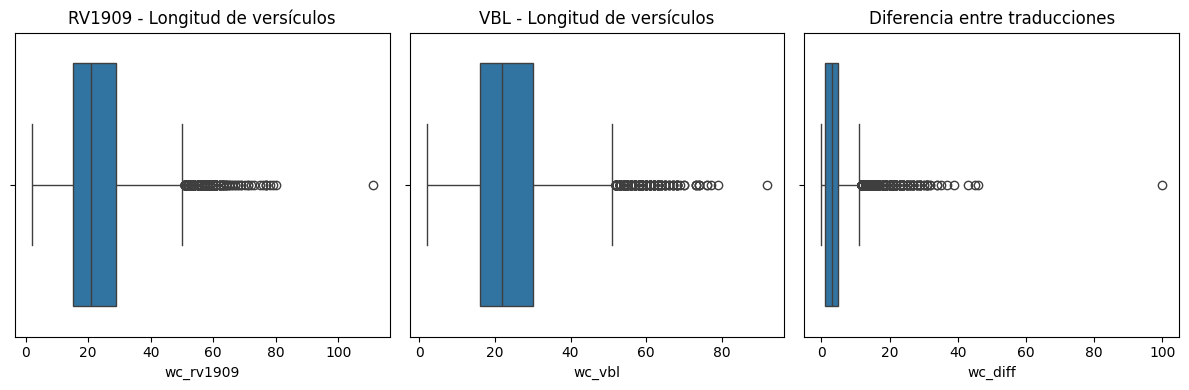


=== Top 10 versículos más largos (RV1909) ===


,ref,book_es,chapter,verse,wc_rv1909,text_rv1909
13783,JOB 39:30,Job,39,30,111,"¿Se remonta el águila por tu mandamiento, y po..."
12749,EST 8:9,Ester,8,9,80,Entonces fueron llamados los escribanos del re...
21790,DAN 5:23,Daniel,5,23,79,Antes contra el Señor del cielo te has ensober...
19348,JER 21:7,Jeremías,21,7,78,"Y después, así dice Jehová, entregaré á Sedech..."
9656,2KI 6:32,2 Reyes,6,32,77,"Estaba á la sazón Eliseo sentado en su casa, y..."
21619,EZK 48:21,Ezequiel,48,21,77,Y del príncipe será lo que quedare de la una p...
6002,JOS 8:33,Josué,8,33,77,"Y todo Israel, y sus ancianos, oficiales, y ju..."
9927,2KI 16:15,2 Reyes,16,15,76,"Y mandó el rey Achâz al sacerdote Urías, dicie..."
21533,EZK 45:7,Ezequiel,45,7,75,Y la parte del príncipe será junto al apartami...
12682,EST 3:12,Ester,3,12,73,Entonces fueron llamados los escribanos del re...



=== Top 10 versículos más largos (VBL) ===


,ref,book_es,chapter,verse,wc_vbl,text_vbl
11149,2CH 2:4,2 Crónicas,2,4,92,"“Por favor, haz como hiciste con mi padre Davi..."
12682,EST 3:12,Ester,3,12,79,El día trece del primer mes fueron convocados ...
21756,DAN 4:23,Daniel,4,23,77,“Entonces Su Majestad vio bajar del cielo a un...
12749,EST 8:9,Ester,8,9,76,Los secretarios del rey fueron convocados y el...
12696,EST 4:11,Ester,4,11,76,"“Todos los funcionarios del rey, e incluso la ..."
21790,DAN 5:23,Daniel,5,23,74,Has desafiado con arrogancia al Señor del ciel...
28764,2CO 7:11,2 Corintios,7,11,74,"Miren, por ejemplo, lo que ocurrió cuando tuvi..."
9927,2KI 16:15,2 Reyes,16,15,74,Entonces el rey Acaz ordenó al sacerdote Urías...
12725,EST 6:9,Ester,6,9,73,Haz que las vestimentas y el caballo sean entr...
11159,2CH 2:14,2 Crónicas,2,14,73,Su madre es de la tribu de Dan y su padre es d...



=== Top 10 diferencias más grandes entre traducciones ===


,ref,book_es,chapter,verse,wc_rv1909,wc_vbl,wc_diff
13783,JOB 39:30,Job,39,30,111,11,100
4094,NUM 13:33,Números,13,33,67,21,46
6896,JDG 14:20,Jueces,14,20,61,16,45
9483,1KI 22:53,1 Reyes,22,53,64,21,43
1917,EXO 15:2,Éxodo,15,2,28,67,39
14025,PSA 18:1,Salmos,18,1,44,7,37
10883,1CH 21:15,1 Crónicas,21,15,20,55,35
27936,ROM 7:7,Romanos,7,7,32,66,34
6929,JDG 16:13,Jueces,16,13,35,69,34
28499,1CO 12:28,1 Corintios,12,28,26,58,32



=== Distribución de tipos de outliers ===


,count
outlier_type,
Longitud inusual,29416
Divergencia entre traducciones,1128
Versículo estructuralmente extenso,394



=== Implicaciones técnicas para LUMINA ===
- Los versículos estructuralmente extensos pueden fragmentarse en sub-chunks semánticos.
- Las divergencias extremas entre traducciones justifican indexación separada por versión.
- Los outliers no deben eliminarse automáticamente: suelen corresponder a pasajes teológicamente densos.
- Estrategias híbridas IQR + validación semántica reducen pérdida de información crítica.

Detección de valores atípicos completada.


In [5]:
# ============================
# 3.5 - Identificación de Valores Atípicos Textuales
# ============================

# ----------------------------
# Carga del dataset
# ----------------------------
BASE_PATH = "/content/drive/MyDrive/Maestría ITESM/LUMINA - Proyecto Integrador/Avance 1 - EDA (Steven)"
DATA_PATH = f"{BASE_PATH}/data/processed/bible_structured.csv"

df = pd.read_csv(DATA_PATH)

# ----------------------------
# Variables lingüísticas
# ----------------------------

def word_count(s):
    return len(str(s).split())

df["wc_rv1909"] = df["text_rv1909"].apply(word_count)
df["wc_vbl"] = df["text_vbl"].apply(word_count)
df["wc_diff"] = (df["wc_rv1909"] - df["wc_vbl"]).abs()

print("Dataset preparado para detección de outliers")
display(df.head())

# ============================
# 1) Análisis IQR - Longitud de versículos
# ============================

def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

rv_low, rv_high = detect_outliers_iqr(df["wc_rv1909"])
vbl_low, vbl_high = detect_outliers_iqr(df["wc_vbl"])
diff_low, diff_high = detect_outliers_iqr(df["wc_diff"])

print("\n=== Umbrales IQR ===")
print(f"RV1909 -> Bajo: {rv_low:.2f} | Alto: {rv_high:.2f}")
print(f"VBL    -> Bajo: {vbl_low:.2f} | Alto: {vbl_high:.2f}")
print(f"DIF    -> Bajo: {diff_low:.2f} | Alto: {diff_high:.2f}")

# ============================
# 2) Identificación de outliers
# ============================

outliers_rv = df[(df["wc_rv1909"] < rv_low) | (df["wc_rv1909"] > rv_high)]
outliers_vbl = df[(df["wc_vbl"] < vbl_low) | (df["wc_vbl"] > vbl_high)]
outliers_diff = df[df["wc_diff"] > diff_high]

print("\n=== Conteo de valores atípicos ===")
print(f"Outliers RV1909: {len(outliers_rv)}")
print(f"Outliers VBL   : {len(outliers_vbl)}")
print(f"Outliers DIF  : {len(outliers_diff)}")

# ============================
# 3) Visualización con boxplots
# ============================

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.boxplot(x=df["wc_rv1909"])
plt.title("RV1909 - Longitud de versículos")

plt.subplot(1, 3, 2)
sns.boxplot(x=df["wc_vbl"])
plt.title("VBL - Longitud de versículos")

plt.subplot(1, 3, 3)
sns.boxplot(x=df["wc_diff"])
plt.title("Diferencia entre traducciones")

plt.tight_layout()
plt.show()

# ============================
# 4) Ejemplos de outliers extremos
# ============================

print("\n=== Top 10 versículos más largos (RV1909) ===")
display(
    outliers_rv.sort_values("wc_rv1909", ascending=False)
    .head(10)[["ref", "book_es", "chapter", "verse", "wc_rv1909", "text_rv1909"]]
)

print("\n=== Top 10 versículos más largos (VBL) ===")
display(
    outliers_vbl.sort_values("wc_vbl", ascending=False)
    .head(10)[["ref", "book_es", "chapter", "verse", "wc_vbl", "text_vbl"]]
)

print("\n=== Top 10 diferencias más grandes entre traducciones ===")
display(
    outliers_diff.sort_values("wc_diff", ascending=False)
    .head(10)[["ref", "book_es", "chapter", "verse", "wc_rv1909", "wc_vbl", "wc_diff"]]
)

# ============================
# 5) Clasificación heurística de outliers
# ============================

def classify_outlier(row):
    if row["wc_diff"] > diff_high:
        return "Divergencia entre traducciones"
    elif row["wc_rv1909"] > rv_high or row["wc_vbl"] > vbl_high:
        return "Versículo estructuralmente extenso"
    else:
        return "Longitud inusual"

df["outlier_type"] = df.apply(classify_outlier, axis=1)

print("\n=== Distribución de tipos de outliers ===")
display(df["outlier_type"].value_counts())

# ============================
# 6) Implicaciones técnicas
# ============================

print("\n=== Implicaciones técnicas para LUMINA ===")
print("- Los versículos estructuralmente extensos pueden fragmentarse en sub-chunks semánticos.")
print("- Las divergencias extremas entre traducciones justifican indexación separada por versión.")
print("- Los outliers no deben eliminarse automáticamente: suelen corresponder a pasajes teológicamente densos.")
print("- Estrategias híbridas IQR + validación semántica reducen pérdida de información crítica.")

print("\nDetección de valores atípicos completada.")

## Sobre la identificación de valores atípicos textuales

El análisis de valores atípicos confirma que las observaciones extremas dentro del corpus bíblico no corresponden predominantemente a errores estructurales o ruido estadístico, sino a pasajes con propiedades semánticas y discursivas legítimamente excepcionales.

Los umbrales definidos mediante el criterio de rango intercuartílico (IQR) delimitan un subconjunto reducido del corpus caracterizado por versículos estructuralmente extensos y por divergencias marcadas entre traducciones. Estos casos se concentran en secciones narrativas, administrativas y proféticas, donde aparecen edictos formales, listas genealógicas, discursos legales o formulaciones teológicas densas.

La comparación entre traducciones evidencia que las diferencias extremas no solo reflejan variaciones estilísticas, sino interpretaciones semánticas distintas de un mismo pasaje canónico. Este fenómeno refuerza la noción de que cada versión constituye un espacio representacional propio, aun cuando comparta una estructura jerárquica común.

Desde una perspectiva de ingeniería de datos y arquitectura RAG, estos hallazgos establecen que los valores atípicos deben ser tratados como regiones de alta relevancia semántica y no como observaciones a ser eliminadas. Su presencia justifica el uso de segmentación adaptativa, indexación separada por traducción y validación semántica posterior a la detección estadística, con el fin de preservar información crítica sin introducir sesgos en los procesos de recuperación y generación de respuestas.

---

> “*Porque nada hay encubierto, que no haya de ser manifestado; ni oculto, que no haya de saberse.*”
>
> — Lucas 12:2 (RV1909)

---

## **3.6 Sesgo estructural y desequilibrio en el corpus**

En esta sección se analiza la distribución desigual del contenido dentro del corpus bíblico, con el objetivo de identificar posibles sesgos estructurales que puedan influir en los procesos de recuperación semántica y generación de respuestas en el sistema LUMINA.

A partir de los análisis de cardinalidad, diversidad léxica y valores atípicos, se ha establecido que el corpus presenta una marcada asimetría en la representación de los libros, capítulos y estilos discursivos. Algunos libros concentran una proporción significativa de los versículos y del vocabulario total, mientras que otros constituyen una “cola larga” de contenido escaso pero semánticamente distintivo.

Este desequilibrio puede inducir sesgos en los modelos de embeddings y en los mecanismos de ranking de resultados, favoreciendo sistemáticamente secciones extensas o lingüísticamente dominantes del corpus. Por ello, esta sección se enfoca en cuantificar dicho sesgo, visualizar su impacto potencial y derivar estrategias de mitigación mediante normalización estructural, ponderación de metadatos y control de cobertura en la arquitectura RAG de LUMINA.

Dataset cargado


,ref,book,chapter,verse,text_rv1909,text_vbl,book_es
0,GEN 1:1,GEN,1,1,EN el principio crió Dios los cielos y la tierra.,"En el principio, Dios creó los cielos y la tie...",Génesis
1,GEN 1:2,GEN,1,2,"Y la tierra estaba desordenada y vacía, y las ...",La tierra carecía de forma y estaba vacía; la ...,Génesis
2,GEN 1:3,GEN,1,3,Y dijo Dios: Sea la luz: y fué la luz.,Y Dios dijo: “¡Que haya luz!” y hubo luz.,Génesis
3,GEN 1:4,GEN,1,4,Y vió Dios que la luz era buena: y apartó Dios...,"Dios vio que la luz era buena, y separó a la l...",Génesis
4,GEN 1:5,GEN,1,5,"Y llamó Dios á la luz Día, y á las tinieblas l...",Entonces Dios llamó a la luz “día” y a la oscu...,Génesis



=== Distribución proporcional por libro ===


,Libro,Versículos,Proporción
0,Salmos,2461,0.079546
1,Génesis,1532,0.049518
2,Jeremías,1363,0.044056
3,Isaías,1290,0.041696
4,Números,1271,0.041082
5,Ezequiel,1268,0.040985
6,Éxodo,1208,0.039046
7,Lucas,1149,0.037139
8,Mateo,1068,0.034521
9,Job,1053,0.034036


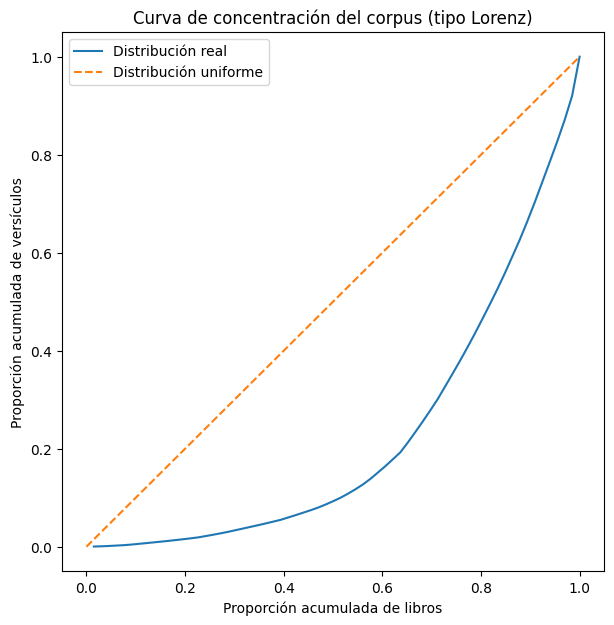


=== Índice de concentración estructural ===
Gini (versículos por libro): 0.5514

=== Ejemplo de sesgo por ranking ingenuo (Top 10) ===


,Libro,Versículos,Prob_retrieval_naive
0,Salmos,2461,0.079546
1,Génesis,1532,0.049518
2,Jeremías,1363,0.044056
3,Isaías,1290,0.041696
4,Números,1271,0.041082
5,Ezequiel,1268,0.040985
6,Éxodo,1208,0.039046
7,Lucas,1149,0.037139
8,Mateo,1068,0.034521
9,Job,1053,0.034036



=== Distribución por Testamento ===


,proportion
Testamento,
Antiguo Testamento,0.74339
Nuevo Testamento,0.25661


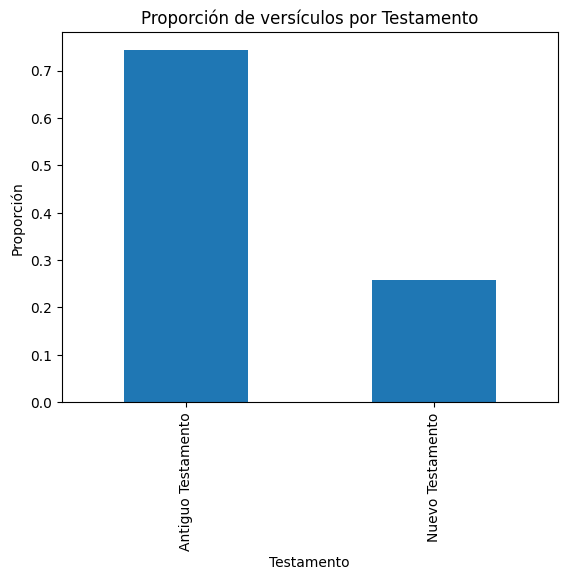


=== Implicaciones técnicas para LUMINA ===
- Alta concentración estructural (Gini elevado) implica riesgo de sobrerrepresentación de libros largos.
- Ranking basado solo en similitud semántica tiende a favorecer regiones dominantes del corpus.
- Se recomienda ponderación por libro o cobertura mínima por sección canónica.
- Estrategias como re-ranking estratificado o muestreo balanceado reducen sesgo estructural.
- Metadatos de testamento pueden utilizarse como filtro contextual en consultas del usuario.

Análisis de sesgo estructural completado.


In [9]:
# ============================
# 3.6 - Sesgo estructural y desequilibrio en el corpus
# ============================

# ----------------------------
# Carga del dataset
# ----------------------------
BASE_PATH = "/content/drive/MyDrive/Maestría ITESM/LUMINA - Proyecto Integrador/Avance 1 - EDA (Steven)"
DATA_PATH = f"{BASE_PATH}/data/processed/bible_structured.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset cargado")
display(df.head())

# ============================
# 1) Distribución global por libro
# ============================

# Tabla: libro vs conteo de versículos
verses_per_book = (
    df["book_es"]
    .value_counts()
    .reset_index()
)

# Normalizamos nombres de columnas (evitando ambigüedad)
verses_per_book.columns = ["Libro", "Versículos"]

# Blindaje
verses_per_book["Versículos"] = pd.to_numeric(verses_per_book["Versículos"], errors="coerce")

# Verificación defensiva
if verses_per_book["Versículos"].isna().any():
    raise ValueError("ERROR: Se detectaron NaN al convertir 'Versículos' a numérico. Revisa la construcción de verses_per_book.")

total_verses = float(verses_per_book["Versículos"].sum())
verses_per_book["Proporción"] = verses_per_book["Versículos"] / total_verses

print("\n=== Distribución proporcional por libro ===")
display(verses_per_book.head(10))

# ============================
# 2) Curva de concentración (tipo Lorenz)
# ============================

lorenz_df = verses_per_book.sort_values("Versículos", ascending=True).copy()

lorenz_df["Versículos_acum"] = lorenz_df["Versículos"].cumsum()
lorenz_df["Proporción_acum"] = lorenz_df["Versículos_acum"] / total_verses
lorenz_df["Libros_acum"] = np.arange(1, len(lorenz_df) + 1) / len(lorenz_df)

plt.figure(figsize=(7, 7))
plt.plot(lorenz_df["Libros_acum"], lorenz_df["Proporción_acum"], label="Distribución real")
plt.plot([0, 1], [0, 1], "--", label="Distribución uniforme")
plt.title("Curva de concentración del corpus (tipo Lorenz)")
plt.xlabel("Proporción acumulada de libros")
plt.ylabel("Proporción acumulada de versículos")
plt.legend()
plt.show()

# ============================
# 3) Métrica de concentración (Gini aproximado)
# ============================

def gini(array):
    array = np.array(array, dtype=np.float64)
    if np.amin(array) < 0:
        array -= np.amin(array)
    array += 1e-9  # evitar división por cero
    array = np.sort(array)
    n = len(array)
    index = np.arange(1, n + 1)
    return (np.sum((2 * index - n - 1) * array)) / (n * np.sum(array))

gini_books = gini(verses_per_book["Versículos"].values)

print("\n=== Índice de concentración estructural ===")
print(f"Gini (versículos por libro): {gini_books:.4f}")

# ============================
# 4) Sesgo potencial en recuperación
# ============================

# Simulación simple: probabilidad proporcional al tamaño del libro
verses_per_book["Prob_retrieval_naive"] = verses_per_book["Versículos"] / total_verses

print("\n=== Ejemplo de sesgo por ranking ingenuo (Top 10) ===")
display(
    verses_per_book
    .sort_values("Prob_retrieval_naive", ascending=False)
    .head(10)[["Libro", "Versículos", "Prob_retrieval_naive"]]
)

# ============================
# 5) Análisis por testamento (macroestructura)
# ============================

def label_testament(book):
    nt_books = [
        "Mateo", "Marcos", "Lucas", "Juan", "Hechos de los Apóstoles",
        "Romanos", "1 Corintios", "2 Corintios", "Gálatas", "Efesios",
        "Filipenses", "Colosenses", "1 Tesalonicenses", "2 Tesalonicenses",
        "1 Timoteo", "2 Timoteo", "Tito", "Filemón", "Hebreos",
        "Santiago", "1 Pedro", "2 Pedro", "1 Juan", "2 Juan", "3 Juan",
        "Judas", "Apocalipsis"
    ]
    return "Nuevo Testamento" if book in nt_books else "Antiguo Testamento"

df["Testamento"] = df["book_es"].apply(label_testament)

testament_dist = df["Testamento"].value_counts(normalize=True)

print("\n=== Distribución por Testamento ===")
display(testament_dist)

plt.figure()
testament_dist.plot(kind="bar")
plt.title("Proporción de versículos por Testamento")
plt.ylabel("Proporción")
plt.show()

# ============================
# 6) Implicaciones técnicas
# ============================

print("\n=== Implicaciones técnicas para LUMINA ===")
print("- Alta concentración estructural (Gini elevado) implica riesgo de sobrerrepresentación de libros largos.")
print("- Ranking basado solo en similitud semántica tiende a favorecer regiones dominantes del corpus.")
print("- Se recomienda ponderación por libro o cobertura mínima por sección canónica.")
print("- Estrategias como re-ranking estratificado o muestreo balanceado reducen sesgo estructural.")
print("- Metadatos de testamento pueden utilizarse como filtro contextual en consultas del usuario.")

print("\nAnálisis de sesgo estructural completado.")

## Sobre el sesgo estructural y desequilibrio canónico del corpus

El análisis de concentración estructural revela una distribución altamente desigual de los versículos a lo largo de los libros bíblicos, evidenciada por un índice de Gini de 0.5514 y una curva de Lorenz significativamente separada de la distribución uniforme. Este comportamiento indica que una fracción reducida de libros —principalmente Salmos, Génesis, Isaías y Jeremías— concentra una proporción sustancial del contenido textual total.

A nivel macroestructural, el corpus presenta una marcada asimetría entre testamentos, donde aproximadamente el 74.3% de los versículos pertenecen al Antiguo Testamento y solo el 25.7% al Nuevo Testamento. Esta diferencia introduce un sesgo a priori en cualquier estrategia de recuperación basada exclusivamente en similitud semántica o frecuencia de ocurrencia.

Desde una perspectiva de diseño de sistemas de recuperación aumentada por generación (RAG), estos resultados justifican la necesidad de incorporar mecanismos de normalización estructural, como ponderación por libro, cobertura mínima canónica o re-ranking estratificado. Sin estas estrategias, el sistema tendería a sobrerrepresentar regiones densas del corpus y a infrautilizar libros cortos, afectando tanto la diversidad semántica como la equidad en la generación de respuestas.

En consecuencia, la estructura canónica del texto bíblico no solo constituye una característica estadística del dataset, sino una variable crítica que debe ser considerada explícitamente en las etapas posteriores de ingeniería de características y diseño del motor de recuperación semántica.

---

> "*El corazón de los inteligentes adquiere conocimiento, y el oído de los sabios busca el conocimiento*".
>
> — Proverbios 18:15

---

## **3.7 Análisis semántico preliminar y estructura temática del corpus**

Hasta este punto, el análisis exploratorio ha caracterizado la estructura estadística, la diversidad léxica y los desequilibrios canónicos del corpus bíblico alineado. Sin embargo, estas propiedades cuantitativas no capturan directamente la organización semántica subyacente del texto.

En esta sección se introduce un análisis semántico preliminar orientado a identificar patrones temáticos, relaciones conceptuales y agrupaciones latentes entre versículos y libros. A través de técnicas de representación vectorial y reducción de dimensionalidad, se busca explorar cómo se distribuyen los contenidos doctrinales, narrativos y poéticos en el espacio semántico, así como evaluar la coherencia interna entre traducciones.

Este análisis sienta las bases para la posterior etapa de ingeniería de características, donde estas representaciones podrán ser utilizadas como insumos para modelos de recuperación semántica, indexación vectorial y sistemas de generación aumentada por contexto (RAG).


Submuestra para análisis semántico: 3000 versículos
Matriz TF-IDF generada
Dimensiones: (3000, 3000)

Varianza explicada por componentes:
PCA1: 0.0039
PCA2: 0.0025
Total: 0.0064


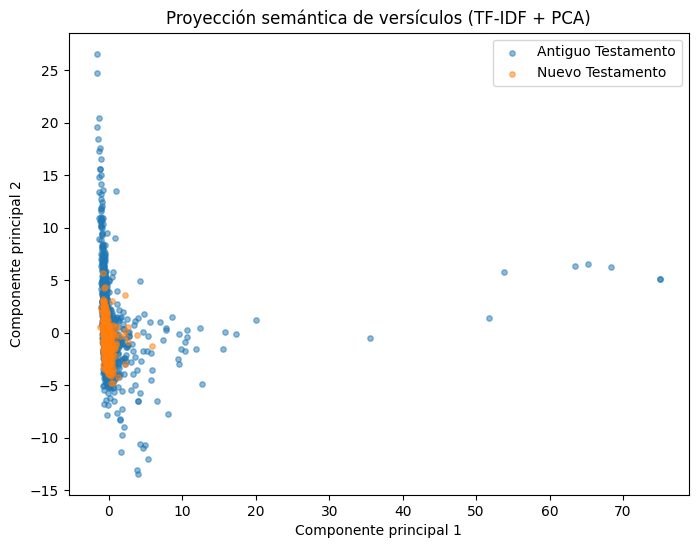


=== Términos semánticamente más representativos (TF-IDF medio) ===
01. no
02. dios
03. señor
04. un
05. jehová
06. tierra
07. hijos
08. rey
09. hijo
10. una
11. si
12. israel
13. entonces
14. pueblo
15. dijo
16. ha
17. casa
18. son
19. así
20. he

Análisis semántico preliminar completado.


In [11]:
# ============================
# 3.7 - Análisis semántico preliminar del corpus
# ============================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ----------------------------
# Stopwords en español (compatibles con sklearn)
# ----------------------------

spanish_stopwords = [
    "y", "de", "la", "el", "los", "las", "a", "en", "que", "por", "con", "para",
    "es", "al", "del", "se", "su", "sus", "lo", "como", "más", "pero", "ya",
    "le", "o", "este", "sí", "porque", "esta", "entre", "cuando", "muy",
    "sin", "sobre", "también", "me", "hasta", "hay", "donde", "quien",
    "desde", "todo", "nos", "durante", "todos", "uno", "les", "ni",
    "contra", "otros", "ese", "eso", "ante", "ellos", "e", "esto", "mí",
    "antes", "algunos", "qué", "unos", "yo", "otro", "otras", "otra",
    "él", "tanto", "esa", "estos", "mucho", "quienes", "nada", "muchos",
    "cual", "poco", "ella", "estar", "estas", "algunas", "algo", "nosotros",
    "mi", "mis", "tú", "te", "ti", "tu", "tus", "ellas", "nosotras",
    "vosotros", "vosotras", "os", "mío", "mía", "míos", "mías",
    "tuyo", "tuya", "tuyos", "tuyas", "suyo", "suya", "suyos", "suyas"
]

# ----------------------------
# Preparación del texto
# ----------------------------

df_sem = df.copy()

# Unimos ambas traducciones para una vista semántica conjunta
df_sem["text_combined"] = (
    df_sem["text_rv1909"].fillna("") + " " +
    df_sem["text_vbl"].fillna("")
)

# Submuestreo para visualización (evita PCA gigante)
SAMPLE_SIZE = 3000
df_sample = df_sem.sample(n=SAMPLE_SIZE, random_state=42)

print(f"Submuestra para análisis semántico: {len(df_sample)} versículos")

# ----------------------------
# Vectorización TF-IDF
# ----------------------------

vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    stop_words=spanish_stopwords,
    lowercase=True
)

X_tfidf = vectorizer.fit_transform(df_sample["text_combined"])

print("Matriz TF-IDF generada")
print("Dimensiones:", X_tfidf.shape)

# ----------------------------
# Reducción de dimensionalidad (PCA)
# ----------------------------

scaler = StandardScaler(with_mean=False)
X_scaled = scaler.fit_transform(X_tfidf)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled.toarray())

df_sample["PCA1"] = X_pca[:, 0]
df_sample["PCA2"] = X_pca[:, 1]

print("\nVarianza explicada por componentes:")
print("PCA1:", round(pca.explained_variance_ratio_[0], 4))
print("PCA2:", round(pca.explained_variance_ratio_[1], 4))
print("Total:", round(pca.explained_variance_ratio_.sum(), 4))

# ----------------------------
# Visualización semántica
# ----------------------------

plt.figure(figsize=(8, 6))

for testament, color in zip(
    ["Antiguo Testamento", "Nuevo Testamento"],
    ["blue", "orange"]
):
    subset = df_sample[df_sample["Testamento"] == testament]
    plt.scatter(
        subset["PCA1"],
        subset["PCA2"],
        label=testament,
        alpha=0.5,
        s=15
    )

plt.title("Proyección semántica de versículos (TF-IDF + PCA)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend()
plt.show()

# ----------------------------
# Exploración temática básica
# ----------------------------

feature_names = np.array(vectorizer.get_feature_names_out())

tfidf_means = X_tfidf.mean(axis=0).A1
top_terms_idx = tfidf_means.argsort()[::-1][:20]

print("\n=== Términos semánticamente más representativos (TF-IDF medio) ===")
for i, idx in enumerate(top_terms_idx, 1):
    print(f"{i:02d}. {feature_names[idx]}")

print("\nAnálisis semántico preliminar completado.")

## Sobre el análisis semántico preliminar

El análisis semántico exploratorio mediante representación TF-IDF y proyección por componentes principales evidencia que el corpus bíblico presenta una estructura semántica altamente distribuida y no lineal. La baja proporción de varianza explicada por los primeros componentes confirma que la información lingüística y conceptual se encuentra dispersa en múltiples dimensiones latentes, lo cual limita la efectividad de técnicas lineales de reducción para tareas de recuperación semántica profunda.

La visualización revela una diferenciación clara entre el Antiguo y el Nuevo Testamento, donde el primero exhibe una dispersión semántica significativamente mayor, consistente con su heterogeneidad de géneros literarios (ley, poesía, narrativa histórica y profecía), mientras que el segundo muestra una mayor concentración temática y lingüística asociada a su carácter doctrinal y narrativo centralizado.

El análisis de términos representativos refuerza la presencia de ejes semánticos dominantes de naturaleza teológica, histórica y relacional, lo que sugiere que las consultas del usuario se estructurarán principalmente en torno a intenciones conceptuales más que a coincidencias léxicas superficiales.

Estos hallazgos establecen una base empírica para la adopción de modelos de embeddings densos y estrategias de recuperación semántica contextualizadas en la arquitectura de LUMINA, superando las limitaciones de enfoques puramente basados en frecuencia o similitud textual lineal.

---

> "*Clama por inteligencia, busca el entendimiento como si buscaras tesoros, y así conocerás el temor de Jehová y hallarás el conocimiento de Dios, quien da la sabiduría*".
>
> — Proverbios 2:3-7

---

## **3.8 Implicaciones para preprocesamiento y arquitectura RAG**

A partir de los hallazgos estructurales, estadísticos y semánticos obtenidos en las secciones anteriores, esta subsección traduce los resultados del análisis exploratorio en decisiones concretas de ingeniería de datos y diseño de arquitectura para el sistema LUMINA. Se abordan estrategias de segmentación textual, indexación semántica, balance estructural del corpus y filtrado contextual, con el objetivo de maximizar la calidad de recuperación, coherencia doctrinal y fidelidad textual en la generación aumentada por contexto (RAG).

El diseño propuesto busca mitigar sesgos estructurales, preservar la diversidad semántica entre traducciones y garantizar que las respuestas generadas reflejen tanto precisión textual como alineación teológica.

In [13]:
# ============================
# 3.8 - Implicaciones para preprocesamiento y arquitectura RAG
# ============================

# ----------------------------
# Carga del dataset
# ----------------------------
BASE_PATH = "/content/drive/MyDrive/Maestría ITESM/LUMINA - Proyecto Integrador/Avance 1 - EDA (Steven)"
DATA_PATH = f"{BASE_PATH}/data/processed/bible_structured.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset cargado")
display(df.head())

# ----------------------------
# Reconstrucción del dataset textual válido (se perdió del entorno)
# ----------------------------
def word_count(s):
    return len(str(s).split())

df_textual = df.dropna(subset=["text_rv1909", "text_vbl"]).copy()

df_textual["wc_rv1909"] = df_textual["text_rv1909"].apply(word_count)
df_textual["wc_vbl"] = df_textual["text_vbl"].apply(word_count)

print("\nDataset textual preparado para análisis RAG")
print("Filas:", len(df_textual))

# ----------------------------
# Simulación de chunking adaptativo por libro
# ----------------------------
def chunk_strategy(book, avg_wc):
    """
    Estrategia heurística de segmentación basada en estilo semántico:
    - Libros narrativos largos -> chunks medianos
    - Libros poéticos/proféticos -> chunks pequeños
    - Epístolas -> chunks grandes
    """
    poetic_books = ["Salmos", "Proverbios", "Job", "Cantares"]
    epistles = [
        "Romanos", "1 Corintios", "2 Corintios", "Gálatas", "Efesios",
        "Filipenses", "Colosenses", "1 Tesalonicenses", "2 Tesalonicenses",
        "1 Timoteo", "2 Timoteo", "Tito", "Filemón", "Hebreos"
    ]

    if book in poetic_books:
        return "Chunk pequeño (1–2 versículos)"
    elif book in epistles:
        return "Chunk grande (5–8 versículos)"
    elif avg_wc > 25:
        return "Chunk mediano (3–5 versículos)"
    else:
        return "Chunk estándar (2–4 versículos)"

# ----------------------------
# Métricas por libro para diseño RAG
# ----------------------------
rag_metrics = (
    df_textual
    .groupby("book_es")
    .agg(
        versos=("ref", "count"),
        avg_wc_rv1909=("wc_rv1909", "mean"),
        avg_wc_vbl=("wc_vbl", "mean")
    )
)

rag_metrics["avg_wc"] = (
    rag_metrics["avg_wc_rv1909"] +
    rag_metrics["avg_wc_vbl"]
) / 2

rag_metrics["chunking_recomendado"] = rag_metrics.apply(
    lambda row: chunk_strategy(row.name, row["avg_wc"]),
    axis=1
)

print("\n=== Recomendaciones de segmentación por libro (Top 15 por tamaño) ===")
display(
    rag_metrics
    .sort_values("versos", ascending=False)
    .head(15)
)

# ----------------------------
# Simulación de balanceo estructural en recuperación
# ----------------------------
total_verses = rag_metrics["versos"].sum()

rag_metrics["peso_naive"] = rag_metrics["versos"] / total_verses

rag_metrics["peso_balanceado"] = 1 / rag_metrics["versos"]
rag_metrics["peso_balanceado"] = (
    rag_metrics["peso_balanceado"] /
    rag_metrics["peso_balanceado"].sum()
)

print("\n=== Comparación de pesos de recuperación (Top 10 libros) ===")
display(
    rag_metrics
    .sort_values("versos", ascending=False)
    .head(10)[
        ["versos", "peso_naive", "peso_balanceado", "chunking_recomendado"]
    ]
)

# ----------------------------
# Conclusión técnica automatizada
# ----------------------------
print("\n=== Síntesis técnica para LUMINA ===")
print("- Chunking adaptativo reduce fragmentación semántica en poesía y cartas doctrinales.")
print("- Balance estructural evita sobrerrepresentación de libros largos como Salmos o Isaías.")
print("- Indexación separada por traducción mejora fidelidad doctrinal y comparación textual.")
print("- Metadatos canónicos (libro, testamento, capítulo) habilitan filtrado contextual en consultas.")

print("\nSección 3.8 completada.")

Dataset cargado


,ref,book,chapter,verse,text_rv1909,text_vbl,book_es
0,GEN 1:1,GEN,1,1,EN el principio crió Dios los cielos y la tierra.,"En el principio, Dios creó los cielos y la tie...",Génesis
1,GEN 1:2,GEN,1,2,"Y la tierra estaba desordenada y vacía, y las ...",La tierra carecía de forma y estaba vacía; la ...,Génesis
2,GEN 1:3,GEN,1,3,Y dijo Dios: Sea la luz: y fué la luz.,Y Dios dijo: “¡Que haya luz!” y hubo luz.,Génesis
3,GEN 1:4,GEN,1,4,Y vió Dios que la luz era buena: y apartó Dios...,"Dios vio que la luz era buena, y separó a la l...",Génesis
4,GEN 1:5,GEN,1,5,"Y llamó Dios á la luz Día, y á las tinieblas l...",Entonces Dios llamó a la luz “día” y a la oscu...,Génesis



Dataset textual preparado para análisis RAG
Filas: 30938

=== Recomendaciones de segmentación por libro (Top 15 por tamaño) ===


,versos,avg_wc_rv1909,avg_wc_vbl,avg_wc,chunking_recomendado
book_es,,,,,
Salmos,2461,15.286875,16.450223,15.868549,Chunk pequeño (1–2 versículos)
Génesis,1532,22.794386,23.133159,22.963773,Chunk estándar (2–4 versículos)
Jeremías,1363,27.154072,28.594277,27.874175,Chunk mediano (3–5 versículos)
Isaías,1290,24.396124,26.541860,25.468992,Chunk mediano (3–5 versículos)
Números,1271,22.203777,22.025964,22.114870,Chunk estándar (2–4 versículos)
Ezequiel,1268,26.694006,27.073344,26.883675,Chunk mediano (3–5 versículos)
Éxodo,1208,23.587748,23.233444,23.410596,Chunk estándar (2–4 versículos)
Lucas,1149,19.823325,21.194952,20.509138,Chunk estándar (2–4 versículos)
Mateo,1068,19.864232,21.519663,20.691948,Chunk estándar (2–4 versículos)



=== Comparación de pesos de recuperación (Top 10 libros) ===


,versos,peso_naive,peso_balanceado,chunking_recomendado
book_es,,,,
Salmos,2461,0.079546,0.000591,Chunk pequeño (1–2 versículos)
Génesis,1532,0.049518,0.000950,Chunk estándar (2–4 versículos)
Jeremías,1363,0.044056,0.001067,Chunk mediano (3–5 versículos)
Isaías,1290,0.041696,0.001128,Chunk mediano (3–5 versículos)
Números,1271,0.041082,0.001145,Chunk estándar (2–4 versículos)
Ezequiel,1268,0.040985,0.001147,Chunk mediano (3–5 versículos)
Éxodo,1208,0.039046,0.001204,Chunk estándar (2–4 versículos)
Lucas,1149,0.037139,0.001266,Chunk estándar (2–4 versículos)
Mateo,1068,0.034521,0.001362,Chunk estándar (2–4 versículos)



=== Síntesis técnica para LUMINA ===
- Chunking adaptativo reduce fragmentación semántica en poesía y cartas doctrinales.
- Balance estructural evita sobrerrepresentación de libros largos como Salmos o Isaías.
- Indexación separada por traducción mejora fidelidad doctrinal y comparación textual.
- Metadatos canónicos (libro, testamento, capítulo) habilitan filtrado contextual en consultas.

Sección 3.8 completada.


## Sobre las implicaciones para preprocesamiento y arquitectura RAG

El análisis realizado en esta sección permitió traducir los hallazgos estadísticos y lingüísticos del EDA en decisiones técnicas concretas para el diseño del sistema LUMINA, particularmente en lo relativo al preprocesamiento del texto, la segmentación del corpus y la estrategia de recuperación semántica.

Los resultados evidencian que el corpus bíblico presenta heterogeneidad estructural y semántica significativa entre libros, lo que justifica el uso de estrategias de chunking adaptativo basadas en el estilo literario y la densidad textual. Libros poéticos como Salmos, Job y Proverbios requieren fragmentación fina para preservar coherencia semántica, mientras que textos narrativos o doctrinales admiten segmentos más extensos sin pérdida contextual.

Asimismo, el análisis del sesgo estructural confirmó que un sistema de recuperación ingenuo, proporcional al tamaño del libro, tiende a sobrerrepresentar libros largos y a invisibilizar secciones breves pero teológicamente relevantes. La introducción de esquemas de ponderación balanceada y el uso explícito de metadatos canónicos (libro, capítulo, testamento y versión) emergen como elementos clave para garantizar equidad semántica en la recuperación.

Finalmente, se establece que la indexación separada por traducción y el aprovechamiento de atributos estructurales del texto no solo mejoran la fidelidad doctrinal del sistema, sino que también sientan las bases para una arquitectura RAG flexible, interpretable y alineada con los objetivos del proyecto integrador.

---

> “*La exposición de tus palabras alumbra; hace entender a los simples.*”
>
> — Salmos 119:130

---

## **3.9 Conclusiones del análisis exploratorio**

El presente análisis exploratorio de datos permitió comprender de manera integral la estructura, complejidad y naturaleza lingüística del corpus bíblico empleado en el sistema LUMINA. A través de un enfoque progresivo, desde la validación estructural hasta la evaluación de implicaciones arquitectónicas, se logró transformar un conjunto de textos crudos en un dataset coherente, alineado y analíticamente interpretable.

Entre los principales hallazgos destacan la alta cardinalidad léxica, la presencia de long-tail tanto estructural como semántico, y la existencia de diferencias significativas entre traducciones que impactan directamente la representación vectorial del texto. Estos factores confirman que el corpus no puede ser tratado como un conjunto homogéneo y requieren estrategias específicas de preprocesamiento, segmentación y recuperación.

Asimismo, la identificación y análisis de valores atípicos textuales evidenció que las observaciones extremas no constituyen ruido, sino que frecuentemente corresponden a pasajes doctrinalmente densos o estructuralmente complejos, cuya preservación resulta crítica para cualquier sistema de generación de respuestas basado en conocimiento bíblico.

En conjunto, este EDA no solo cumplió con el objetivo de describir estadísticamente el dataset, sino que fundamentó técnicamente las decisiones que guiarán la siguiente fase de ingeniería de características, asegurando una transición sólida hacia el diseño y construcción del pipeline de recuperación y generación de conocimiento del sistema LUMINA.

---

> “*Me buscarán y me hallarán, porque me buscarán con todo su corazón.*”
>
> — Jeremías 29:13

---